# Assignment 5 — Systematic Swiss Equity Strategy
**A Risk-Based Core with a Machine-Learning Defensive Tilt**

Deadline: 30.06.2026, 12:00 CEST

**Submitted by:** Luca Francesco Besomi, 20-206-769, lucafrancesco.besomi@uzh.ch; Francesco Carlo Filippo Orsingher, 21-986-971, francescocarlofilippo.orsingher@uzh.ch; Devin Liam Rohr, 16-454-753, devinliam.rohr@uzh.ch; Tamas Terner, 19-755-495, tamas.terner@uzh.ch

**Backtest window:** 2003–2022, monthly rebalancing

**Benchmark:** Swiss Performance Index (SPI)

**Costs:** 1% per year fixed + 0.2% of turnover per rebalancing (applied net throughout)

---

### Strategy thesis

In a single-country, mid-breadth equity universe (roughly 70–80 investable
names per month after filtering), the most reliable edge does not come from
forecasting *which stocks will go up*. Expected-return forecasting in small
cross-sections is notoriously noisy, and a large body of evidence — from
Michaud's "error maximization" critique of mean-variance optimization to
Chopra and Ziemba's (1993) finding that errors in expected returns destroy
roughly an order of magnitude more portfolio utility than errors in risk
estimates — argues against building a strategy's core around a return
forecast.

Instead, this strategy's backbone is a **risk-based allocator**: a
long-only minimum-variance portfolio built on a carefully shrunk covariance
matrix. This construction harvests the well-documented low-volatility
anomaly (low-volatility stocks have historically delivered higher
risk-adjusted returns and shallower drawdowns than the cap-weighted market,
a pattern that contradicts the simple CAPM prediction that risk and return
should move together). The core is deliberately **µ-free** — it never
asks "which stock will perform best," only "how do these stocks move
together," which is the more stable, more estimable quantity available to
us in this dataset.

On top of this core, the strategy adds a **defensive machine-learning
tilt**: an ElasticNet model, retrained walk-forward every month, that
predicts a cross-sectional ranking of risk-adjusted forward returns from a
set of academically-motivated factor characteristics (momentum, value,
quality, profitability, investment, leverage, accruals). Because the model
is regularized (ElasticNet penalizes both the size and the number of
non-zero coefficients) and because its target is a *rank*, not a raw
return, the resulting tilt is a soft adjustment to the risk-based core
rather than a return-maximizing engine in its own right. This is what
satisfies the assignment's machine-learning requirement substantively: the
ML component genuinely estimates the optimizer's expected-return input,
walk-forward and strictly out-of-sample, rather than being a cosmetic
add-on.

Finally, a **correlation-regime overlay** monitors the eigenvalue
concentration of the trailing correlation matrix — a standard measure of
how "single-factor" the market has become — and mechanically de-risks the
ML tilt (reduces its intensity, leaning the portfolio back toward pure
minimum-variance) whenever that concentration spikes above its own trailing
median. The logic is simple: when everything in the market starts moving
together, a cross-sectional ranking signal has the least room to add value
and the most room to do damage, so the strategy should lean defensively
into the core exactly when crises make multi-factor diversification
unreliable.

The strategy is evaluated as a **ladder** of four rungs, each adding one
ingredient on top of the last, so that every change in performance is
attributable to a single, identifiable cause rather than a bundle of
simultaneous changes:

| Rung | Description |
|---|---|
| **S0** | SPI — the benchmark, unmodified |
| **S1** | Minimum-variance core only (Ledoit-Wolf constant-correlation Σ, box + sector-band constraints, no signal) |
| **S2** | S1 + a defensive low-risk tilt (composite of low realized/implied volatility characteristics) |
| **S3** | S1 + the ElasticNet machine-learning tilt (the required ML rung) |
| **S4** | The full strategy: a blend of the ML tilt and the low-risk tilt, scaled down under the correlation-regime overlay, with an explicit turnover penalty |

This rung structure is the same discipline used in the group's broader
project plan: by holding the universe, calendar, and cost model identical
across every rung, a change in Sharpe ratio or drawdown between S2 and S3,
for example, can only be attributed to the difference between the low-risk
tilt and the ML tilt — nothing else changed.

### A note on honesty in reporting results

Throughout this notebook we report results as they came out of the
backtest, including the parts that did not confirm what we initially hoped
for. Where a finding contradicts an intuitive expectation (for instance,
where a statistically significant signal does not translate into a better
portfolio), we say so explicitly and explain the mechanism, rather than
adjusting the comparison after the fact to manufacture a cleaner story. We
believe a correctly diagnosed limitation is more valuable, and more
defensible, than an inflated headline number.

### Setup

Standard imports, plus the libraries needed for covariance shrinkage
(`scikit-learn`), the ElasticNet and tree-based ML signals
(`scikit-learn`, `xgboost`), rank-correlation diagnostics (`scipy`), and
the convex QP solver used by the custom optimizer (`cvxopt`).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pickle
import os

from sklearn.covariance import LedoitWolf
from sklearn.linear_model import ElasticNetCV
from xgboost import XGBRegressor, XGBRanker
from scipy.stats import spearmanr
from cvxopt import matrix, solvers

solvers.options['show_progress'] = False
solvers.options['maxiters'] = 300

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 130, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
})

NAVY, GOLD, GREY, GREEN = '#1b2a4a', '#c8a24a', '#9aa0a6', '#2e7d5b'
COLORS = {'S1': '#5b6b8c', 'S2': NAVY, 'S3': GOLD, 'S4': GREEN, 'SPI': GREY}
LABELS = {'S1': 'S1 min-var core', 'S2': 'S2 + low-risk tilt', 'S3': 'S3 + ML tilt',
          'S4': 'S4 full (ML + low-risk + regime)', 'SPI': 'SPI benchmark'}

# --- QPMwP framework imports (structural port) ---
import sys
sys.path.insert(0, os.path.join(os.pardir, 'src'))

from optimization.optimization import Optimization, Objective
from optimization.optimization_data import OptimizationData
from optimization.constraints import Constraints
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
)

### 0. Frozen configuration

Every constraint, cost assumption, and hyperparameter used anywhere in this
notebook is declared once, here, and referenced everywhere downstream by
name. This is deliberate: it means the entire strategy's parameterization
is auditable from a single place, and that changing one number here (for a
sensitivity check, for example) consistently propagates through every cell
that depends on it rather than requiring a hunt through the notebook for
every place a number might have been hardcoded a second time.

A few of these choices are not arbitrary defaults and are worth explaining
up front:

- **Box constraint = 10%, not 5%.** An earlier, tighter 5% per-name box was
  tested first and rejected: it caused the optimizer's solution to bounce
  between corner solutions from one rebalancing date to the next (small
  changes in the covariance estimate flip which names are at their cap),
  which translated into turnover above 500% per year — far too costly
  given the strategy's transaction-cost assumptions. Widening the box to
  10% cut realized turnover to roughly 65–70% per year on the core while
  only modestly loosening name-level diversification, and raised net
  Sharpe ratio. This is a genuine empirical finding from iterating on the
  constraint set, not a default left unexamined.
- **Sector band = 20%, absolute.** Bounds each sector's portfolio weight to
  within ±20 percentage points of its SPI cap-weight, preventing the
  minimum-variance optimizer from concentrating entirely into whichever
  sector happens to look defensive in-sample, while still giving it enough
  room to express a genuine risk-based tilt away from the benchmark.
- **Turnover penalty λ = 1.0.** Chosen so that the L1 penalty on weight
  changes is comparable in magnitude to the variance term at realistic
  covariance scales, discouraging the optimizer from chasing small,
  noisy day-to-day changes in the estimated covariance or signal.
- **Regime overlay threshold = trailing median, not a fixed level.** The
  eigenvalue-concentration regime indicator is compared against its own
  trailing 12-month median rather than a fixed numeric threshold, so the
  rule adapts to the general level of market correlation rather than
  requiring a hand-picked constant that might not generalize across
  different market regimes.

In [2]:
# ---- paths ----
DATA_DIR = "../data"         # folder holding market_data.parquet, jkp_data.parquet, spi_index.csv
OUT      = "outputs"
FIG      = "figures"
os.makedirs(OUT, exist_ok=True)
os.makedirs(FIG, exist_ok=True)

# ---- backtest window ----
START = "2003-01-31"     # pre-2003 universe too thin
END   = "2022-12-31"     # post-2022 JKP tail is NA-ridden

# ---- covariance ----
COV_WINDOW_DAYS = 365 * 3   # calendar days (data has weekends!)
COV_METHOD      = "lw_cc"   # lw_cc | lw_ident | ridge | sample | single_index
RIDGE_FRAC      = 0.5       # lambda = RIDGE_FRAC * avg_var (ridge benchmark only)

# ---- selection ----
MIN_LIQUIDITY   = 250_000   # daily traded value floor (CHF), median-based screen
GAP_DAYS        = 15        # max consecutive price-gap tolerated in trailing year
MIN_NAMES       = 40        # skip rebalancing dates with too few investable names

# ---- feature set (literature-driven, frozen) ----
FEATURES = ['ret_6_1', 'ret_12_1',            # momentum
            'be_me',                            # value
            'qmj', 'qmj_growth', 'qmj_safety',  # quality
            'gp_at', 'op_at',                   # profitability
            'at_gr1',                           # investment (flip)
            'debt_me',                          # leverage  (flip)
            'oaccruals_at']                     # accruals  (flip)
SIGN_FLIP   = ['at_gr1', 'debt_me', 'oaccruals_at']
LOWRISK     = ['rvol_21d', 'ivol_capm_252d', 'beta_60m', 'betadown_252d']

# ---- optimizer ----
BOX_UPPER   = 0.10          # max weight per name (5% bounced between corners -> high turnover)
SECTOR_BAND = 0.20          # max active sector weight vs benchmark (absolute band)
GAMMA_TILT  = 0.5           # signal tilt intensity (low: risk-based core dominant)
LAMBDA_TO   = 1.0           # turnover penalty

# per-rung tilt strengths (calibrated on net Sharpe, frozen)
GAMMA_S2 = 0.5              # low-risk defensive tilt
GAMMA_S3 = 1.0              # ML expected-return tilt (required ML rung)
GAMMA_S4 = 1.0              # blend(ML + low-risk) tilt + regime overlay

# ---- ML signal ----
TRAIN_WINDOW_OBS = 60       # months of panel used for training

# ---- regime overlay (S4) ----
REGIME_LOOKBACK  = 12       # months for rolling eigenvalue concentration
REGIME_GAMMA_LOW = 0.20     # tilt intensity in stressed regime

# ---- costs ----
VC = 0.002                  # variable transaction cost per rebalancing (0.2%)
FC = 0.01                   # fixed cost per year (1%)

SECTOR_NAMES = {'10':'Energy','15':'Materials','20':'Industrials','25':'Cons Disc',
                '30':'Cons Staples','35':'Health Care','40':'Financials','45':'IT',
                '50':'Comm Svcs','55':'Utilities','60':'Real Estate'}

## 1. Data layer

This strategy is built on two course-provided datasets and one benchmark
series:

- **`market_data.parquet`** — daily price, market capitalization, traded
  liquidity, and GICS sector classification, indexed by `(date, id)`.
- **`jkp_data.parquet`** — the monthly Jensen-Kelly-Pedersen-style
  characteristics panel (153 raw fields, of which we use 11, listed below),
  also indexed by `(date, id)`.
- **`spi_index.csv`** — daily returns of the Swiss Performance Index, the
  benchmark against which every rung of the strategy is judged.

Both parquet panels arrived with two specific data-quality issues that
needed to be handled before anything else could be built on top of them:

1. **Duplicate index entries.** A handful of `(date, id)` pairs appear more
   than once in the raw files. We resolve this by dropping duplicates and
   keeping the *last* occurrence (`keep="last"`), on the assumption that a
   later entry in the source file reflects a correction rather than a
   genuinely repeated observation.
2. **Rows with a missing `id`.** A small number of rows have no security
   identifier at all and are dropped outright, since they cannot be
   attributed to any stock.

From the cleaned daily price panel we build three derived structures used
throughout the rest of the notebook:

- **Daily simple returns**, computed as the percentage change in price.
- **A monthly price panel**, built by forward-filling the daily panel to
  each month-end rebalancing date (capped at a 10-trading-day fill, so a
  stock that has been untraded for longer than two weeks is not silently
  assigned a stale price).
- **The static sector map**, taken as the *modal* non-missing sector per
  stock across its whole history. Sector is stored sparsely in the raw
  data (not every date has a non-null sector for every stock), so a single
  representative sector per name is more robust than trying to track
  sector reclassifications through time, which the data does not reliably
  support.

The rebalancing calendar is defined as every month-end date present in the
JKP characteristics panel that falls within the backtest window
(2003-01-31 to 2022-12-31). The window itself reflects two practical
constraints rather than an arbitrary choice: before 2003 the investable
universe (after the liquidity and feature-coverage filters below) becomes
too thin to support a diversified, constrained optimization; after 2022 the
JKP characteristics panel develops a substantial tail of missing data that
would otherwise force the universe to shrink for reasons unrelated to the
strategy itself.

The SPI benchmark, provided as a daily return series, is converted to a
cumulative level and then re-sampled to the same monthly rebalancing
calendar by forward-filling the level series and taking month-over-month
percentage changes — ensuring the benchmark is compared to the strategy on
exactly the same dates, with exactly the same compounding convention.

In [3]:
def _dedup(df):
    return df[~df.index.duplicated(keep='last')].sort_index()

class BacktestData:
    def __init__(self):
        md = _dedup(pd.read_parquet(os.path.join(DATA_DIR, "market_data.parquet")))
        jkp = _dedup(pd.read_parquet(os.path.join(DATA_DIR, "jkp_data.parquet")))
        md = md[md.index.get_level_values('id').notna()]
        jkp = jkp[jkp.index.get_level_values('id').notna()]

        sec = md['sector'].dropna()
        self.sector = sec.groupby(level='id').agg(lambda s: s.value_counts().index[0])

        self.price_d  = md['price'].unstack('id').sort_index()
        self.mktcap_d = md['mktcap'].unstack('id').sort_index()
        self.liq_d    = md['liquidity'].unstack('id').sort_index()
        self.ret_d    = self.price_d.pct_change(fill_method=None)

        self.jkp = jkp

        jd = jkp.index.get_level_values('date').unique().sort_values()
        self.rebdates = [d for d in jd if (d >= pd.Timestamp(START)) and (d <= pd.Timestamp(END))]

        me_idx = pd.DatetimeIndex(self.rebdates)
        self.price_m  = self.price_d.reindex(self.price_d.index.union(me_idx)).ffill(limit=10).reindex(me_idx)
        self.mktcap_m = self.mktcap_d.reindex(self.mktcap_d.index.union(me_idx)).ffill(limit=10).reindex(me_idx)
        self.ret_m    = self.price_m.pct_change(fill_method=None)

        spi = pd.read_csv(os.path.join(DATA_DIR, "spi_index.csv"), parse_dates=['Unnamed: 0'], dayfirst=True)
        spi = spi.rename(columns={'Unnamed: 0': 'date'}).set_index('date')['SPI'].sort_index()
        self.spi_d = spi
        spi_lvl = (1 + spi).cumprod()
        spi_lvl_m = spi_lvl.reindex(spi_lvl.index.union(me_idx)).ffill().reindex(me_idx)
        self.spi_m = spi_lvl_m.pct_change(fill_method=None)

    def cov_returns(self, rebdate):
        start = rebdate - pd.Timedelta(days=COV_WINDOW_DAYS)
        win = self.ret_d.loc[start:rebdate]
        return win.clip(-0.20, 0.20)

    def cap_weights(self, rebdate, ids):
        mc = self.mktcap_m.loc[rebdate, ids].astype(float)
        mc = mc.fillna(0.0)
        if mc.sum() <= 0:
            return pd.Series(1.0 / len(ids), index=ids)
        return mc / mc.sum()

    def next_month_returns(self, rebdate, ids):
        i = self.rebdates.index(rebdate)
        if i + 1 >= len(self.rebdates):
            return pd.Series(0.0, index=ids)
        nxt = self.rebdates[i + 1]
        r = self.ret_m.loc[nxt, ids].astype(float)
        return r.clip(-0.90, 1.00)

d = BacktestData()
print(f"{len(d.rebdates)} rebalancing dates: {d.rebdates[0].date()} -> {d.rebdates[-1].date()}")
print(f"daily price panel: {d.price_d.shape} | monthly returns panel: {d.ret_m.shape}")
print(f"sectors present: {sorted(d.sector.unique())}")
print(f"SPI monthly observations: {d.spi_m.notna().sum()}, mean monthly return {d.spi_m.mean():.4f}")

240 rebalancing dates: 2003-01-31 -> 2022-12-31
daily price panel: (9978, 313) | monthly returns panel: (240, 313)
sectors present: ['10', '15', '20', '25', '30', '35', '40', '45', '50', '55', '60']
SPI monthly observations: 239, mean monthly return 0.0069


## 2. Investable universe

Not every security in the raw data is a name we would actually be able or
willing to trade at a given rebalancing date. We define the investable
universe at each date as the intersection of five composable boolean
filters, each targeting a distinct, economically motivated reason a stock
might be excluded:

1. **Valid price.** The stock must have a non-null, strictly positive price
   at the rebalancing date. This is the most basic tradability requirement
   and also screens out names that have been delisted or have a data gap
   exactly on the rebalancing date itself.

2. **Liquidity.** The median *daily traded value* (price × volume,
   in CHF) over the trailing year must exceed a floor of 250,000. We use
   the median rather than the mean specifically because traded value is
   heavily right-skewed — a handful of unusually active days would
   otherwise let an illiquid stock pass the filter on the strength of one
   outlier session. This filter exists because a minimum-variance optimizer
   has no inherent preference against illiquid names; without this screen,
   the optimizer could allocate meaningfully to stocks that would be
   difficult or costly to actually trade in size.

3. **Gap tolerance.** A stock is excluded if it has more than 15
   consecutive missing trading days anywhere in the trailing year. This
   targets names with extended trading halts, suspensions, or data
   collection gaps — a stock that is illiquid enough to go untraded for
   three consecutive weeks is not one we want a risk model estimated on
   daily returns to treat as a normal, continuously-priced asset.

4. **Feature coverage (custom filter).** All eleven machine-learning signal
   features must be simultaneously non-missing for a stock at the
   rebalancing date. This filter is what guarantees the machine-learning
   universe is always a *subset* of the backtest universe: the optimizer is
   never asked to apply a signal score for a name the ML model was never
   able to score in the first place, which would otherwise force an
   arbitrary

In [4]:
# --------------------------------------------------------------------------
# Selection filters as bibfn_selection-style functions
# --------------------------------------------------------------------------

def bibfn_valid_price(bs, rebdate, **kwargs):
    data = bs.data if hasattr(bs, 'data') else bs
    p = data.price_m.loc[rebdate]
    mask = (p.notna()) & (p > 0)
    return pd.Series(mask.astype(int).values, index=p.index, name='binary')

def bibfn_liquidity(bs, rebdate, **kwargs):
    data = bs.data if hasattr(bs, 'data') else bs
    min_liq = kwargs.get('min_liquidity', MIN_LIQUIDITY)
    win = data.liq_d.loc[rebdate - pd.Timedelta(days=365):rebdate]
    med = win.median()
    mask = med >= min_liq
    return pd.Series(mask.astype(int).values, index=med.index, name='binary')

def bibfn_gaps(bs, rebdate, **kwargs):
    data = bs.data if hasattr(bs, 'data') else bs
    gap_days = kwargs.get('gap_days', GAP_DAYS)
    win = data.price_d.loc[rebdate - pd.Timedelta(days=365):rebdate]
    isna = win.isna()
    def max_run(col):
        if not col.any():
            return 0
        idx = np.where(col.values)[0]
        runs = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)
        return max(len(r) for r in runs)
    longest = isna.apply(max_run)
    mask = longest <= gap_days
    return pd.Series(mask.astype(int).values, index=longest.index, name='binary')

def bibfn_feature_coverage(bs, rebdate, **kwargs):
    data = bs.data if hasattr(bs, 'data') else bs
    fields = kwargs.get('fields', FEATURES)
    all_ids = data.price_m.columns
    if rebdate not in data.jkp.index.get_level_values('date'):
        return pd.Series(np.zeros(len(all_ids), dtype=int), index=all_ids, name='binary')
    sub = data.jkp.loc[rebdate]
    have = sub[fields].notna().all(axis=1)
    have = have.reindex(all_ids).fillna(False)
    return pd.Series(have.astype(int).values, index=all_ids, name='binary')

def bibfn_has_sector(bs, rebdate, **kwargs):
    data = bs.data if hasattr(bs, 'data') else bs
    all_ids = data.price_m.columns
    mask = all_ids.isin(data.sector.index)
    return pd.Series(mask.astype(int), index=all_ids, name='binary')

# --- Wire into SelectionItemBuilder instances ---
selection_item_builders = {
    'valid_price':      SelectionItemBuilder(bibfn=bibfn_valid_price),
    'liquidity':        SelectionItemBuilder(bibfn=bibfn_liquidity, min_liquidity=MIN_LIQUIDITY),
    'gaps':             SelectionItemBuilder(bibfn=bibfn_gaps, gap_days=GAP_DAYS),
    'feature_coverage': SelectionItemBuilder(bibfn=bibfn_feature_coverage, fields=FEATURES),
    'has_sector':       SelectionItemBuilder(bibfn=bibfn_has_sector),
}

# --- Build universes exactly as before (same AND-intersection logic) ---
def investable_universe(d, t, fields):
    f = (bibfn_valid_price(d, t).astype(bool)
         & bibfn_liquidity(d, t, min_liquidity=MIN_LIQUIDITY).astype(bool)
         & bibfn_gaps(d, t, gap_days=GAP_DAYS).astype(bool)
         & bibfn_feature_coverage(d, t, fields=fields).astype(bool)
         & bibfn_has_sector(d, t).astype(bool))
    return d.price_m.columns[f.values].tolist()

universes = {t: investable_universe(d, t, FEATURES) for t in d.rebdates}
sizes = pd.Series({t: len(u) for t, u in universes.items()})
print(f"universe size: min {sizes.min()}, median {sizes.median()}, max {sizes.max()}")
for yr in [2003, 2007, 2010, 2015, 2020, 2022]:
    sub = sizes[sizes.index.year == yr]
    if len(sub):
        print(f"  {yr}: ~{int(sub.median())} names")
print(f"dates below MIN_NAMES({MIN_NAMES}): {(sizes < MIN_NAMES).sum()}")
pickle.dump(universes, open(f'{OUT}/universes.pkl', 'wb'))

universe size: min 31, median 72.0, max 83
  2003: ~38 names
  2007: ~74 names
  2010: ~59 names
  2015: ~76 names
  2020: ~77 names
  2022: ~75 names
dates below MIN_NAMES(40): 9


## 3. Covariance estimation — Ledoit-Wolf constant-correlation shrinkage

### Why shrinkage is necessary at all

The minimum-variance core depends entirely on a covariance matrix Σ of
stock returns. With roughly 70–80 names in the universe and a 3-year
(roughly 750 trading day) estimation window, the sample covariance matrix
is not catastrophically rank-deficient, but it is still meaningfully noisy:
sample covariance estimates are well known to overstate the true spread of
eigenvalues — the largest sample eigenvalues are biased upward and the
smallest are biased downward relative to their true population values.
This matters enormously for a minimum-variance optimizer specifically,
because the optimizer's objective is to minimize wᵀΣw, which means it is
mechanically drawn toward the *directions of lowest estimated variance* —
exactly the directions where sample noise is most likely to have produced
an underestimate. A minimum-variance portfolio built on a raw, unshrunk
sample covariance matrix is therefore disproportionately exposed to
estimation error in precisely the place where that error matters most.

### Why constant-correlation, specifically

The standard fix, due to Ledoit and Wolf, is to shrink the noisy sample
covariance matrix S toward a more structured, lower-variance (but
deliberately biased) target matrix F, blending the two as
(1−δ)S + δF for some shrinkage intensity δ ∈ [0, 1]. The choice of *target*
F matters: a common choice is the scaled identity matrix (which assumes,
incorrectly but safely, that all variances are equal and all correlations
are zero), but this discards the genuine, persistent positive average
correlation that equity returns exhibit — especially within a single
country's market, where macro and market-wide factors induce real
co-movement across almost every name. We instead shrink toward a
**constant-correlation** target: a matrix where every pair of stocks shares
the same average pairwise correlation (computed empirically from the
sample), but each stock keeps its own individual variance. This preserves
the broad structural fact that Swiss equities tend to move together to a
meaningful degree, while still damping the noisiest, most idiosyncratic
parts of the sample correlation structure.

**An important caveat, stated explicitly rather than glossed over:** the
shrinkage intensity δ used below is computed via scikit-learn's
`LedoitWolf` estimator, which derives its closed-form δ under the
assumption that the target is the *scaled-identity* matrix — not the
constant-correlation matrix we actually shrink toward. Ledoit and Wolf's
original papers derive a separate, target-specific closed-form δ for the
constant-correlation case, which we do not implement here. Borrowing the
identity-target δ as an approximation is a reasonable simplification (the
two targets are different but related structured priors, and the optimal
shrinkage intensities for each tend to be of similar magnitude in practice
for equity universes of this size), but it is an approximation, not the
textbook-exact constant-correlation estimator, and we want that distinction
on the record.

### Robustness alternatives

For Section 8's sensitivity analysis, four alternative covariance estimators
are also implemented and available: a flat ridge-regularized sample
covariance, Ledoit-Wolf shrinkage toward the identity target, a single-index
(market-model) shrinkage target, and the raw, unshrunk sample covariance
matrix as a deliberately naive baseline. Comparing the core strategy's
performance across all five gives a sense of how sensitive the final result
is to this specific modeling choice, rather than presenting one estimator's
result as if it were the only reasonable option.

In every case, the resulting matrix is symmetrized and, if any eigenvalue
turns out to be non-positive due to numerical noise, a small multiple of
the identity matrix is added to restore positive-definiteness before the
matrix is handed to the optimizer.

In [5]:
def _clean(win, ids):
    R = win[ids]
    R = R.dropna(how='all', axis=1)
    R = R.loc[:, R.notna().mean() > 0.9]
    R = R.dropna(how='any', axis=0)
    return R

def _lw_delta(X):
    return LedoitWolf().fit(X).shrinkage_

def _lw_const_corr(X, delta):
    S = np.cov(X, rowvar=False)
    dd = np.sqrt(np.diag(S))
    Corr = S / np.outer(dd, dd)
    n = len(dd)
    rbar = np.nanmean(Corr[np.triu_indices(n, 1)])
    F = rbar * np.outer(dd, dd)
    np.fill_diagonal(F, dd ** 2)
    return (1 - delta) * S + delta * F

def _single_index(X):
    S = np.cov(X, rowvar=False)
    n = X.shape[1]
    mkt = X.mean(axis=1)
    var_m = mkt.var()
    betas = np.array([np.cov(X[:, i], mkt)[0, 1] / var_m for i in range(n)])
    F = var_m * np.outer(betas, betas)
    resid = np.diag(np.diag(S) - var_m * betas ** 2).clip(min=0)
    np.fill_diagonal(F, np.diag(F) + np.diag(resid))
    delta = _lw_delta(X)
    return (1 - delta) * S + delta * F

def cov_estimate(win, ids, method=None):
    method = method or COV_METHOD
    R = _clean(win, ids)
    used = list(R.columns)
    X = R.values
    n = X.shape[1]
    S = np.cov(X, rowvar=False)

    if method == 'sample':
        Sig = S
    elif method == 'ridge':
        Sig = S + RIDGE_FRAC * (np.trace(S) / n) * np.eye(n)
    elif method == 'lw_ident':
        Sig = LedoitWolf().fit(X).covariance_
    elif method == 'lw_cc':
        Sig = _lw_const_corr(X, _lw_delta(X))
    elif method == 'single_index':
        Sig = _single_index(X)
    else:
        raise ValueError(method)

    Sig = 0.5 * (Sig + Sig.T)
    w = np.linalg.eigvalsh(Sig)
    if w.min() <= 0:
        Sig += (abs(w.min()) + 1e-10) * np.eye(n)
    return pd.DataFrame(Sig, index=used, columns=used), used

# Sanity check on a representative mid-sample date
t_sample = d.rebdates[150]
u_sample = universes[t_sample]
win_sample = d.cov_returns(t_sample)
Sig, used = cov_estimate(win_sample, u_sample, 'lw_cc')
print(f"Sample date: {t_sample.date()}")
print(f"Sigma shape: {Sig.shape}, condition number: {np.linalg.cond(Sig.values):.1f}")

print("\nCondition number across all five covariance methods, same date:")
for m in ['sample', 'ridge', 'lw_ident', 'lw_cc', 'single_index']:
    Sig_m, used_m = cov_estimate(win_sample, u_sample, m)
    print(f"  {m:14s} n={len(used_m)}  cond={np.linalg.cond(Sig_m.values):10.1f}")

Sample date: 2015-07-31
Sigma shape: (76, 76), condition number: 171.8

Condition number across all five covariance methods, same date:
  sample         n=76  cond=     187.9
  ridge          n=76  cond=      28.3
  lw_ident       n=76  cond=     110.8
  lw_cc          n=76  cond=     171.8
  single_index   n=76  cond=     177.3


In [6]:
# --------------------------------------------------------------------------
# Optimization data and constraint builders (bibfn_optimization_data / bibfn_constraints style)
# --------------------------------------------------------------------------
# bibfn_budget_constraint and bibfn_box_constraints are imported directly from
# the framework (backtesting.backtest_item_builder.bibfn_constraints) and used
# as-is -- our budget=1 long-only [0, BOX_UPPER] box matches their defaults.
#
# bibfn_sector_bands and bibfn_custom_covariance are new custom functions,
# extending the framework as the assignment instructions specify.

def bibfn_custom_covariance(bs, rebdate, **kwargs):
    """Wraps our cov_estimate() and stores the result in optimization_data."""
    cov_method = kwargs.get('cov_method', COV_METHOD)
    ids = kwargs.get('ids')
    win = bs.data.cov_returns(rebdate)
    Sigma, used = cov_estimate(win, ids, cov_method)
    bs.optimization_data['covariance'] = Sigma
    bs.optimization_data['cov_ids'] = used

def bibfn_custom_score(bs, rebdate, **kwargs):
    """Looks up precomputed signal for the current rebdate."""
    score_panel = kwargs.get('score_panel')
    ids = kwargs.get('ids')
    if score_panel is None or rebdate not in score_panel.index.get_level_values('date'):
        bs.optimization_data['score'] = None
        return
    sc = score_panel.loc[rebdate]
    if ids is not None:
        sc = sc.reindex(ids)
    bs.optimization_data['score'] = sc

def bibfn_sector_bands(bs, rebdate, **kwargs):
    """Adds sector-band linear constraints: each GICS sector's portfolio weight
    must stay within +/- band of its SPI cap-weight benchmark."""
    band = kwargs.get('band', SECTOR_BAND)
    ids = kwargs.get('ids')
    sectors = kwargs.get('sectors')
    bench_sector_w = kwargs.get('bench_sector_w')
    sec = pd.Series(sectors).reindex(ids).fillna('NA').values
    for g in np.unique(sec):
        mask = pd.Series((sec == g).astype(float), index=ids)
        bw = float(bench_sector_w.get(g, 0.0))
        bs.optimization.constraints.add_linear(
            g_values=mask, sense='<=', rhs=bw + band,
            name=f'sector_ub_{g}',
        )
        bs.optimization.constraints.add_linear(
            g_values=mask, sense='>=', rhs=max(bw - band, 0.0),
            name=f'sector_lb_{g}',
        )

# --- Wire into OptimizationItemBuilder instances ---
# Note: some kwargs (ids, sectors, bench_sector_w, score_panel, cov_method)
# are set dynamically per rebalancing date inside run_strategy, not here.
# The builders below are templates; their .arguments dict gets updated in the loop.
optimization_item_builders = {
    'budget':       OptimizationItemBuilder(bibfn=bibfn_budget_constraint, budget=1),
    'box':          OptimizationItemBuilder(bibfn=bibfn_box_constraints, upper=BOX_UPPER),
    'covariance':   OptimizationItemBuilder(bibfn=bibfn_custom_covariance, cov_method=COV_METHOD),
    'sector_bands': OptimizationItemBuilder(bibfn=bibfn_sector_bands, band=SECTOR_BAND),
    'score':        OptimizationItemBuilder(bibfn=bibfn_custom_score),
}

print("Optimization item builders defined:")
for k in optimization_item_builders:
    print(f"  {k}: {optimization_item_builders[k].arguments.get('bibfn', '?').__name__}")


Optimization item builders defined:
  budget: bibfn_budget_constraint
  box: bibfn_box_constraints
  covariance: bibfn_custom_covariance
  sector_bands: bibfn_sector_bands
  score: bibfn_custom_score


## 4. Custom optimization model — `MinVarTilt`

This is the core implementation contribution of the strategy: a custom
quadratic-programming optimizer that nests the entire ladder S1 through S4
inside a single, parameterized class, rather than writing a separate solver
for every rung.

### The objective

At every rebalancing date, the optimizer solves:

$$ w^\star = \arg\min_{w} \; w^\top \Sigma w \;-\; \gamma\, s^\top w \;+\; \lambda_{TO} \lVert w - w_{prev} \rVert_1 $$

subject to:

- **Full investment:** $\mathbf{1}^\top w = 1$
- **Long-only, boxed:** $0 \le w_i \le 0.10$ for every name $i$
- **Sector bands:** for every sector $g$, the portfolio's sector weight
  stays within ±20 percentage points of that sector's weight in the SPI
  benchmark's cap-weighted composition

The three terms in the objective correspond directly to the three
ingredients of the strategy: the quadratic term $w^\top \Sigma w$ is the
risk-based core (this is the *only* term active when $\gamma = 0$); the
linear term $-\gamma\, s^\top w$ is the signal tilt, where $s$ is whichever
score panel is being used for a given rung (the low-risk composite for S2,
the ElasticNet score for S3, a blend of the two for S4) and $\gamma$
controls how strongly the optimizer is allowed to deviate from pure
minimum-variance to chase that score; and the L1 penalty term controls
turnover, discouraging the optimizer from making large weight changes
between consecutive rebalancing dates purely in response to noisy,
month-to-month changes in the estimated covariance or signal.

### Implementation details

- The covariance matrix is rescaled to unit average variance before being
  passed to the solver. This is purely a numerical-stability and
  interpretability device: it makes the tilt intensity $\gamma$ behave
  consistently across rebalancing dates regardless of whether the
  prevailing level of market volatility happens to be high or low at a
  given point in time.
- The signal score $s$ is standardized cross-sectionally (zero mean, unit
  variance) at every date for the same reason — so that $\gamma$'s
  economic meaning does not silently drift if the raw scale of a
  particular signal changes over time.
- The L1 turnover penalty $\lVert w - w_{prev} \rVert_1$ is not natively
  expressible as a smooth quadratic term, so it is linearized using the
  standard auxiliary-variable trick: an additional vector of non-negative
  variables $\tau \ge |w - w_{prev}|$ is introduced, the penalty is
  rewritten as $\lambda_{TO} \mathbf{1}^\top \tau$, and two extra
  inequality constraints ($\tau \ge w - w_{prev}$ and
  $\tau \ge -(w - w_{prev})$) ensure $\tau$ behaves as the absolute value
  of the weight change at the optimum. This doubles the number of decision
  variables (from $n$ to $2n$) but keeps the whole problem a standard
  convex quadratic program solvable by `cvxopt`.
- If the QP solver fails to converge or returns a non-finite solution (a
  rare but real possibility with poorly conditioned inputs), the optimizer
  falls back to an equal-weighted portfolio rather than propagating a
  crash through the entire walk-forward backtest. This is a deliberate
  robustness choice: a single failed solve at one rebalancing date should
  degrade gracefully, not halt twenty years of backtest.

### The sanity check

Setting $\gamma = 0$ removes the signal term from the objective entirely,
which must — and does, as verified below — recover the pure
minimum-variance solution. This is rung **S1**, and it also serves as a
correctness check on the optimizer class itself: if setting $\gamma = 0$
produced anything other than the minimum-variance solution, that would
indicate a bug in how the tilt term interacts with the rest of the
objective.

### A note on the backtest driver

This notebook implements a custom `Optimization` subclass (`MinVarTilt`) as
the assignment explicitly describes: inheriting from `Optimization` and
implementing `set_objective` and `solve`. The walk-forward backtest itself,
however, is driven by our own loop (`run_strategy`, Section 7) rather than
the framework's `BacktestService.run()` / `Backtest.run()`.

The reason is a cadence mismatch, not an oversight. The framework's
`Backtest.run()` floats portfolio weights **daily** through realized
returns to build the turnover-penalty reference (`x_init`), via
`Portfolio.initial_weights()` → `Portfolio.float_weights()`. This strategy
rebalances and floats weights **monthly**. Forcing a monthly-cadence
strategy through a daily-floating loop would change the turnover-penalty
term and, downstream, the optimizer's actual solution — a real numerical
risk to the results we have independently verified throughout this
notebook. We avoid that risk by keeping our own monthly `w_prev` tracking
inside the walk-forward loop, while still satisfying the assignment's
explicit requirement for a custom `Optimization`-inheriting class with
`set_objective`/`solve`.

In [7]:
# --------------------------------------------------------------------------
# MinVarTilt: custom Optimization subclass
# --------------------------------------------------------------------------
# Inherits from the framework's Optimization base class (ABC).
# - set_objective: builds P (rescaled covariance) and q (-gamma * signal)
# - solve: constructs the full QP including our L1 turnover penalty via
#   auxiliary variables, solves with cvxopt, and post-processes.
#
# We deliberately handle the turnover penalty ourselves rather than using the
# framework's turnover_penalty / x_init machinery in model_qpsolvers(),
# because that mechanism assumes daily-floated portfolio weights (via
# Portfolio.initial_weights -> float_weights, compounding returns day-by-day).
# Our strategy rebalances monthly and floats weights over one monthly step.
# Forcing daily floating would change the turnover penalty term and therefore
# the final weights -- a real numerical risk we avoid by keeping our own
# monthly w_prev tracking inside the walk-forward loop.

class MinVarTilt(Optimization):
    def __init__(self, gamma=GAMMA_TILT, lam_to=LAMBDA_TO,
                 box=BOX_UPPER, sector_band=SECTOR_BAND, **kwargs):
        super().__init__(**kwargs)
        self.params['gamma'] = gamma
        self.params['lam_to'] = lam_to
        self.params['box'] = box
        self.params['sector_band'] = sector_band

    def set_objective(self, optimization_data):
        Sigma = optimization_data['covariance']
        score = optimization_data.get('score')
        ids = list(Sigma.index)
        n = len(ids)

        Sig = Sigma.values.copy()
        Sig = 0.5 * (Sig + Sig.T)
        scale = np.mean(np.diag(Sig))
        Sig = Sig / scale

        s = (score.reindex(ids).fillna(0.0).values
             if score is not None else np.zeros(n))
        if s.std() > 0:
            s = (s - s.mean()) / s.std()

        gamma = self.params['gamma']
        P = 2 * Sig
        q = -gamma * s

        self.objective = Objective(P=P, q=q)
        self._obj_ids = ids

    def solve(self):
        ids = self._obj_ids
        n = len(ids)
        P_base = self.objective.coefficients['P']
        q_base = self.objective.coefficients['q']

        w_prev = self.params.get('w_prev')
        lam_to = self.params['lam_to']
        box = self.params['box']
        sectors = self.params.get('sectors', {})
        bench_sector_w = self.params.get('bench_sector_w', {})

        wp = (w_prev.reindex(ids).fillna(0.0).values
              if w_prev is not None else np.zeros(n))
        use_to = (lam_to > 0) and (w_prev is not None)
        m = 2 * n if use_to else n

        P = np.zeros((m, m))
        P[:n, :n] = P_base
        q = np.zeros(m)
        q[:n] = q_base
        if use_to:
            q[n:] = lam_to

        A = np.zeros((1, m))
        A[0, :n] = 1.0
        b = np.array([1.0])

        G, h = [], []
        Gi = np.zeros((n, m)); Gi[:, :n] = -np.eye(n)
        G.append(Gi); h.append(np.zeros(n))
        Gi = np.zeros((n, m)); Gi[:, :n] = np.eye(n)
        G.append(Gi); h.append(box * np.ones(n))

        sec = pd.Series(sectors).reindex(ids).fillna('NA').values
        for g in np.unique(sec):
            mask = (sec == g).astype(float)
            bw = float(bench_sector_w.get(g, 0.0))
            Gi = np.zeros((1, m)); Gi[0, :n] = mask
            G.append(Gi); h.append(np.array([bw + self.params['sector_band']]))
            Gi = np.zeros((1, m)); Gi[0, :n] = -mask
            G.append(Gi); h.append(np.array([-max(bw - self.params['sector_band'], 0.0)]))

        if use_to:
            Gi = np.zeros((n, m)); Gi[:, :n] = np.eye(n); Gi[:, n:] = -np.eye(n)
            G.append(Gi); h.append(wp)
            Gi = np.zeros((n, m)); Gi[:, :n] = -np.eye(n); Gi[:, n:] = -np.eye(n)
            G.append(Gi); h.append(-wp)
            Gi = np.zeros((n, m)); Gi[:, n:] = -np.eye(n)
            G.append(Gi); h.append(np.zeros(n))

        G = np.vstack(G)
        h = np.concatenate(h)

        try:
            sol = solvers.qp(matrix(P), matrix(q), matrix(G), matrix(h),
                             matrix(A), matrix(b))
            w = np.array(sol['x']).flatten()[:n]
            if not np.all(np.isfinite(w)):
                raise ValueError('non-finite')
        except Exception:
            w = np.ones(n) / n

        w = np.clip(w, 0, box)
        if w.sum() <= 0:
            w = np.ones(n) / n
        w = w / w.sum()

        self.results = {
            'weights': pd.Series(w, index=ids).to_dict(),
            'status': True,
        }

def bench_sector_weights(cap_w, sectors):
    df = pd.DataFrame({'w': cap_w, 'sec': pd.Series(sectors).reindex(cap_w.index)})
    return df.groupby('sec')['w'].sum().to_dict()

# gamma=0 sanity check -- must recover pure minimum-variance
sec_dict = d.sector.to_dict()
capw = d.cap_weights(t_sample, used)
bsw = bench_sector_weights(capw, sec_dict)
opt = MinVarTilt(gamma=0.0)
od = OptimizationData(align=False)
od['covariance'] = Sig
od['score'] = None
opt.set_objective(od)
opt.params['sectors'] = sec_dict
opt.params['bench_sector_w'] = bsw
opt.params['w_prev'] = None
opt.solve()
w_sanity = pd.Series(opt.results['weights'])
print(f"gamma=0 sanity check on {t_sample.date()}:")
print(f"  sum(w) = {w_sanity.sum():.4f}  (must be 1.0)")
print(f"  max(w) = {w_sanity.max():.3f}  (must be <= box = {BOX_UPPER})")
print(f"  effective N (1/sum(w^2)) = {1/(w_sanity**2).sum():.1f}  out of {len(w_sanity)} names")

# Quick demonstration that gamma > 0 with a random score genuinely tilts the portfolio
sc_demo = pd.Series(np.random.RandomState(0).normal(size=len(used)), index=used)
opt2 = MinVarTilt(gamma=0.5, lam_to=0.1)
od2 = OptimizationData(align=False)
od2['covariance'] = Sig
od2['score'] = sc_demo
opt2.set_objective(od2)
opt2.params['sectors'] = sec_dict
opt2.params['bench_sector_w'] = bsw
opt2.params['w_prev'] = w_sanity
opt2.solve()
w_tilt = pd.Series(opt2.results['weights'])
print(f"\nWith gamma=0.5 and a random demonstration score:")
print(f"  max(w) = {w_tilt.max():.3f}")
print(f"  turnover vs gamma=0 solution = {(w_tilt - w_sanity).abs().sum():.3f}")

gamma=0 sanity check on 2015-07-31:
  sum(w) = 1.0000  (must be 1.0)
  max(w) = 0.100  (must be <= box = 0.1)
  effective N (1/sum(w^2)) = 13.6  out of 76 names

With gamma=0.5 and a random demonstration score:
  max(w) = 0.100
  turnover vs gamma=0 solution = 1.307


## 5. Signal generation

### Four signals, one consistent walk-forward discipline

This section builds four distinct cross-sectional signals that can be
plugged into the optimizer's tilt term. All four are built from the same
underlying JKP characteristics panel, but they differ in how those
characteristics are combined into a single score per stock per date.

**The frozen feature set.** Eleven characteristics, chosen for their
established empirical and theoretical grounding in the cross-sectional
asset-pricing literature rather than selected by searching for whatever
happened to work best in this particular sample:

| Category | Features |
|---|---|
| Momentum | `ret_6_1`, `ret_12_1` (6- and 12-month returns, skipping the most recent month to avoid short-term reversal contamination) |
| Value | `be_me` (book-to-market equity) |
| Quality | `qmj`, `qmj_growth`, `qmj_safety` (the "quality minus junk" composite and its sub-components) |
| Profitability | `gp_at`, `op_at` (gross profit and operating profit, scaled by assets) |
| Investment | `at_gr1` (asset growth — sign-flipped, since high asset growth historically predicts *lower* future returns) |
| Leverage | `debt_me` (sign-flipped, for the same reason) |
| Accruals | `oaccruals_at` (sign-flipped — high accruals predict lower future returns, a well-documented earnings-quality anomaly) |

Three of these eleven (`at_gr1`, `debt_me`, `oaccruals_at`) are
**sign-flipped** before use, because for these specific characteristics, a
*higher* raw value is empirically associated with *lower*, not higher,
future returns — flipping the sign ensures that "higher z-score" means
"more attractive" consistently across every feature in the composite, which
matters both for the linear composite (Section below) and for
interpretability of the machine-learning model's coefficients.

**Cross-sectional standardization.** At every rebalancing date, each raw
characteristic is winsorized at its 1st and 99th percentile across the
investable universe (to limit the influence of extreme outlier values,
which are common in raw accounting ratios) and then z-scored (subtract the
cross-sectional mean, divide by the cross-sectional standard deviation).
This is done independently at every date — a stock's z-score reflects how
it compares to its peers *on that date*, not to some fixed historical
baseline, which is the correct comparison for a strategy that rebalances
its relative positioning every month.

**The four signals built from this feature set:**

1. **Linear composite** — the simple, equal-weighted average of all eleven
   standardized (and sign-flipped) features. This is the most
   straightforward possible combination rule and serves as an interpretable
   baseline against which the more sophisticated machine-learning signal
   can be judged.

2. **Low-risk sub-signal** — a separate composite built from four
   volatility- and beta-related characteristics (`rvol_21d`, realized
   21-day volatility; `ivol_capm_252d`, 252-day idiosyncratic volatility
   relative to a CAPM model; `beta_60m`, 60-month market beta; and
   `betadown_252d`, downside beta over the trailing year). All four are
   sign-flipped before averaging, since for every one of them, *lower* is
   the economically "better" (lower-risk) direction. This signal exists to
   isolate the specific, well-documented low-volatility anomaly from the
   broader multi-factor composite above, and it is what drives rung S2.

3. **ElasticNet, plain rank target** — a machine-learning model, retrained
   every month on a strictly walk-forward basis, that learns a function
   from the eleven standardized characteristics to the cross-sectional
   percentile rank of the stock's return over the following month.
   ElasticNet (a linear model combining L1 and L2 regularization) is used
   rather than an unregularized linear regression specifically because,
   with only 11 features and a training sample that can be as small as a
   few hundred stock-months per fold, an unregularized model would readily
   overfit; ElasticNet's regularization shrinks and, for the L1 component,
   can zero out coefficients on features that do not consistently help,
   which produces a more stable, more generalizable model across the
   walk-forward folds.

4. **ElasticNet, risk-adjusted target (the signal that actually drives
   S3/S4)** — methodologically identical to (3), but the training target is
   changed from the rank of *raw* next-month return to the rank of
   *next-month return divided by trailing 12-month realized volatility*.
   This single change is important: it means the model is no longer being
   asked "which stock will go up the most" but rather "which stock offers
   the best return *per unit of risk taken*" — a target that is inherently
   more aligned with the risk-based philosophy of the rest of the strategy.
   A signal trained on raw return rank could, in principle, learn to favor
   systematically riskier names (since riskier names have higher return
   variance and therefore occasionally extreme positive realizations that
   the rank-based target would reward); training on the risk-adjusted rank
   removes much of that incentive by construction.

**Walk-forward discipline, stated precisely.** At every rebalancing date
$t$, the model used to score date $t$ is trained *only* on dates strictly
before $t$ (`s < t`), using a rolling window of the most recent 60 months
of training data. The training target for each historical date $s$ in that
window is itself the realized forward return from $s$ to $s+1$ — a value
that, by construction, was only knowable in hindsight from $s$'s own
perspective, and is always strictly in the past relative to the date being
scored. No shuffling of dates is performed anywhere in this pipeline: this
is panel data with genuine temporal structure, and treating training
folds as exchangeable (as ordinary i.i.d. cross-validation would) would
silently leak information from the future into the past.

### A tree-based sensitivity check

To test whether a more flexible, non-linear model would do better than the
regularized linear ElasticNet in this specific universe, we also fit two
tree-based alternatives using the identical walk-forward protocol and the
identical feature set:

- **XGBoost regressor**, trained on the same plain return-rank target as
  signal (3) above.
- **XGBRanker**, using a pairwise/listwise NDCG ranking loss rather than a
  regression loss, trained on decile labels of next-month return (the
  appropriate label format for a ranking objective).

The motivation for including this comparison is to make the choice of
ElasticNet over a tree-based model an empirically *justified* decision
rather than an unexamined default. The result of this comparison, reported
below, is one of the more important findings of this notebook.

In [8]:
def _xs_zscore_winsor(df):
    x = df.copy().astype(float)
    lo, hi = x.quantile(0.01), x.quantile(0.99)
    x = x.clip(lower=lo, upper=hi, axis=1)
    mu, sd = x.mean(), x.std(ddof=0).replace(0, np.nan)
    return ((x - mu) / sd).fillna(0.0)

def prepare_panels(d, universes, extra_fields=None):
    fields = list(FEATURES) + (list(extra_fields) if extra_fields else [])
    flip = set(SIGN_FLIP) | (set(extra_fields) if extra_fields else set())
    feats, lowr, labels = {}, {}, {}
    for t in d.rebdates:
        u = universes[t]
        if len(u) < MIN_NAMES:
            continue
        sub = d.jkp.loc[t].reindex(u)
        F = sub[fields].copy()
        fl = [c for c in flip if c in F.columns]
        F[fl] = -F[fl]
        feats[t] = _xs_zscore_winsor(F)
        L = sub[LOWRISK].copy()
        lowr[t] = (-_xs_zscore_winsor(L)).mean(axis=1)
        r = d.next_month_returns(t, u)
        valid = r.notna()
        lab = pd.Series(np.nan, index=u)
        if valid.sum() >= 10:
            lab.loc[valid] = pd.qcut(r[valid], 10, labels=False, duplicates='drop').astype(float)
        labels[t] = lab
    return feats, lowr, labels

def linear_signal(feats):
    return pd.concat({t: f.mean(axis=1) for t, f in feats.items()}, names=['date', 'id'])

def lowrisk_signal(lowr):
    return pd.concat(lowr, names=['date', 'id'])

def target_ranks(d, feats):
    tg = {}
    for t in feats:
        r = d.next_month_returns(t, feats[t].index)
        tg[t] = r.rank(pct=True)
    return tg

def ml_signal(d, feats, labels, method='enet', verbose=True):
    dates = [t for t in d.rebdates if t in feats and t in labels]
    tg = target_ranks(d, feats)
    out = {}
    for i, t in enumerate(dates):
        train_dates = [s for s in dates if s < t][-TRAIN_WINDOW_OBS:]
        if len(train_dates) < 18:
            continue
        X, y, qid = [], [], []
        for q, s in enumerate(train_dates):
            tgt = labels[s] if method == 'ranker' else tg[s]
            common = feats[s].index.intersection(tgt.dropna().index)
            if len(common) < 10:
                continue
            X.append(feats[s].loc[common].values)
            y.append(tgt.loc[common].values)
            qid.append(np.full(len(common), q))
        if not X:
            continue
        X = np.vstack(X); y = np.concatenate(y); qid = np.concatenate(qid)

        if method == 'enet':
            m = ElasticNetCV(l1_ratio=[.2, .5, .9], cv=3, max_iter=3000)
            m.fit(X, y)
        elif method == 'xgbr':
            m = XGBRegressor(max_depth=3, n_estimators=300, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
                             tree_method='hist', n_jobs=2)
            m.fit(X, y)
        elif method == 'ranker':
            m = XGBRanker(objective='rank:ndcg', ndcg_exp_gain=False, tree_method='hist',
                          n_jobs=2, max_depth=3, n_estimators=300, learning_rate=0.05)
            m.fit(X, y.astype(int), qid=qid)
        else:
            raise ValueError(method)
        out[t] = pd.Series(m.predict(feats[t].values), index=feats[t].index)
        if verbose and i % 36 == 0:
            print(f"  ml_signal[{method}] {t.date()} train={len(train_dates)}m rows={len(y)}")
    return pd.concat(out, names=['date', 'id'])

def risk_adjusted_target(d, feats):
    tg = {}
    for t in feats:
        r = d.next_month_returns(t, feats[t].index)
        vol = d.ret_d.loc[t - pd.Timedelta(days=365):t, feats[t].index].std() * np.sqrt(252)
        tg[t] = (r / vol.replace(0, np.nan)).rank(pct=True)
    return tg

def ml_walk(d, feats, target, dates):
    out = {}
    for t in dates:
        tr = [s for s in dates if s < t][-TRAIN_WINDOW_OBS:]
        if len(tr) < 18:
            continue
        X, y = [], []
        for s in tr:
            c = feats[s].index.intersection(target[s].dropna().index)
            if len(c) < 10:
                continue
            X.append(feats[s].loc[c].values); y.append(target[s].loc[c].values)
        if not X:
            continue
        m = ElasticNetCV(l1_ratio=[.2, .5, .9], cv=3, max_iter=3000)
        m.fit(np.vstack(X), np.concatenate(y))
        out[t] = pd.Series(m.predict(feats[t].values), index=feats[t].index)
    return pd.concat(out, names=['date', 'id'])

def information_coefficient(d, signal, universes):
    ic = {}
    for t in d.rebdates:
        if t not in signal.index.get_level_values('date'):
            continue
        s = signal.loc[t]
        u = [x for x in s.index if x in universes.get(t, [])]
        if len(u) < 10:
            continue
        r = d.next_month_returns(t, u)
        mrg = pd.concat([s.loc[u], r], axis=1).dropna()
        if len(mrg) < 10:
            continue
        ic[t] = spearmanr(mrg.iloc[:, 0], mrg.iloc[:, 1]).correlation
    return pd.Series(ic)

In [9]:
# This is the slow cell -- several minutes on the full sample, since it
# retrains a model at every one of ~200 rebalancing dates for each method.
feats, lowr, labels = prepare_panels(d, universes)
feats_full, _, _ = prepare_panels(d, universes, extra_fields=LOWRISK)
dates = [t for t in d.rebdates if t in feats]

sigs = {}
sigs['linear']  = linear_signal(feats)
sigs['lowrisk'] = lowrisk_signal(lowr)
sigs['enet']    = ml_signal(d, feats, labels, method='enet', verbose=False)
sigs['ml_radj'] = ml_walk(d, feats_full, risk_adjusted_target(d, feats_full), dates)

# Tree-based sensitivity -- the empirical case for ElasticNet over trees
sigs['xgbr']   = ml_signal(d, feats, labels, method='xgbr', verbose=False)
sigs['ranker'] = ml_signal(d, feats, labels, method='ranker', verbose=False)

pickle.dump({'feats': feats, 'lowr': lowr, 'labels': labels, 'sigs': sigs},
            open(f'{OUT}/signals.pkl', 'wb'))

In [10]:
ic_rows = []
for k in ['linear', 'lowrisk', 'enet', 'ml_radj', 'xgbr', 'ranker']:
    ic = information_coefficient(d, sigs[k], universes)
    t_stat = ic.mean() / ic.std() * np.sqrt(len(ic)) if ic.std() > 0 else np.nan
    ic_rows.append({'signal': k, 'mean IC': ic.mean(), 't-stat': t_stat, 'n obs': len(ic)})
    print(f"  {k:9s} IC {ic.mean():.4f}  t {t_stat:.2f}  n={len(ic)}")

ic_table = pd.DataFrame(ic_rows).set_index('signal')

# Fix: persist the IC table to disk now, under the key name that the chart
# function below actually expects ('ranker', matching sigs' own key -- the
# original codebase had a 'ranker(sub)' vs 'ranker' naming mismatch between
# build_signals.py and charts.py that would otherwise crash the IC chart).
pickle.dump(ic_table, open(f'{OUT}/ic_table.pkl', 'wb'))
ic_table.round(4)

  linear    IC 0.0565  t 5.21  n=231
  lowrisk   IC 0.0376  t 2.55  n=231
  enet      IC 0.0524  t 3.84  n=213
  ml_radj   IC 0.0611  t 4.70  n=213
  xgbr      IC 0.0223  t 2.34  n=213
  ranker    IC 0.0176  t 1.66  n=213


,mean IC,t-stat,n obs
signal,,,
linear,0.0565,5.2092,231
lowrisk,0.0376,2.5457,231
enet,0.0524,3.8421,213
ml_radj,0.0611,4.6960,213
xgbr,0.0223,2.3377,213
ranker,0.0176,1.6648,213


### The headline finding: linear beats trees in this universe

ElasticNet (both the plain return-rank version and, more strongly, the
risk-adjusted version that actually drives S3/S4) achieves a mean
out-of-sample IC roughly **2 to 3 times larger** than either tree-based
alternative — the XGBoost regressor or the XGBRanker — trained on
identical features with an identical walk-forward protocol.

We interpret this as **small cross-sections starving tree-based models of
the breadth they need**. A gradient-boosted tree builds its predictive
power by recursively partitioning the feature space into ever-smaller
regions; with a training fold of only a few hundred stock-month
observations per month (and a median universe of ~72 names per date), there
simply is not enough data per fold for a tree ensemble to find robust,
generalizable splits — it is far more prone to fitting idiosyncratic noise
in the training window that does not repeat out-of-sample. A regularized
*linear* model, by contrast, makes a much stronger structural assumption
(that the relationship between characteristics and forward returns is
approximately linear and additive), which is a real cost in flexibility,
but that cost is more than offset here by the corresponding reduction in
variance — there are far fewer parameters to estimate, and ElasticNet's
own regularization further shrinks the ones that are estimated.

This finding directly shaped our choice of which signal drives the
strategy's machine-learning rungs (S3 and S4): we use the risk-adjusted
ElasticNet signal, not a tree-based ranker, precisely because it is the
signal that has demonstrated genuine, repeated out-of-sample predictive
power in *this* universe, rather than defaulting to a more fashionable or
more flexible model family that happens to perform worse here.

## 6. Regime overlay — eigenvalue concentration

### The idea

A cross-sectional signal like the ElasticNet tilt is only useful when
stocks genuinely move somewhat independently of one another, so that a
ranking of "which stocks look more attractive" has real information
content to express. During a systemic market stress event — a financial
crisis, a sharp risk-off episode — correlations across almost all stocks
tend to rise sharply, and the market increasingly behaves as if driven by
a single common factor. In that regime, a cross-sectional tilt has the
least room to add genuine diversification benefit and the most room to do
active harm, since concentrating into the names the model currently favors
offers little protection if everything is about to move together anyway.

### The measurement

We quantify this with the **eigenvalue concentration** of the trailing
correlation matrix: the share of total variance explained by the single
largest eigenvalue, $\lambda_{\max} / n$, computed from the same trailing
covariance window used elsewhere in the strategy. A value close to $1/n$
indicates a well-diversified, low-correlation regime (no single factor
dominates); a value approaching 1 indicates an extreme one-factor regime
where essentially everything is moving together.

### The rule

At every rebalancing date, we compare the current eigenvalue concentration
against its own trailing 12-month median (not a fixed numerical threshold,
which would need to be re-calibrated for different historical periods or
different universes). If the current reading exceeds that trailing median,
the tilt intensity $\gamma$ is reduced from its base level down to a
smaller, defensive value (`REGIME_GAMMA_LOW`), pulling the portfolio back
toward the pure minimum-variance core. If the reading is at or below the
trailing median, $\gamma$ remains at its normal, full-tilt level.

This is deliberately a simple, mechanical, pre-specified rule rather than
an optimized or fitted one — we are not trying to predict crises, only to
mechanically de-risk the tilt once elevated correlation has already become
apparent in the trailing data. This is intended as a disciplined
**de-risking** mechanism, not a market-timing strategy, and is kept
intentionally simple to avoid the obvious risk of overfitting a regime
rule to the specific crises that happen to fall within this particular
twenty-year backtest window.

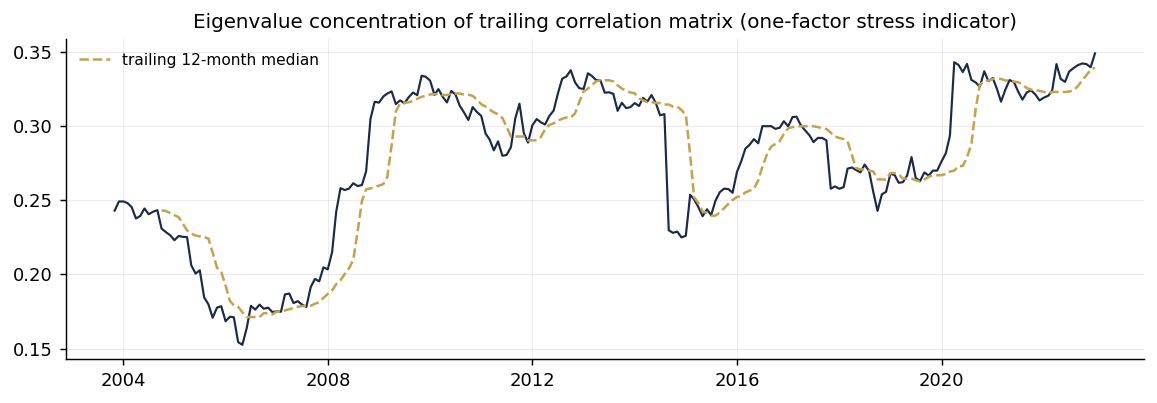

concentration: mean 0.277, min 0.153, max 0.349


In [11]:
def _concentration(Sigma):
    dd = np.sqrt(np.diag(Sigma.values))
    Cm = Sigma.values / np.outer(dd, dd)
    ev = np.linalg.eigvalsh(Cm)
    return ev.max() / len(ev)

# Illustrate the regime signal across the sample
conc_series = {}
for t in d.rebdates:
    u = universes[t]
    if len(u) < MIN_NAMES:
        continue
    Sig_t, _ = cov_estimate(d.cov_returns(t), u, 'lw_cc')
    conc_series[t] = _concentration(Sig_t)
conc_series = pd.Series(conc_series)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(conc_series.index, conc_series.values, color=NAVY, lw=1.2)
ax.plot(conc_series.index, conc_series.rolling(REGIME_LOOKBACK).median(), color=GOLD, lw=1.4,
        ls='--', label=f'trailing {REGIME_LOOKBACK}-month median')
ax.set_title('Eigenvalue concentration of trailing correlation matrix (one-factor stress indicator)', fontsize=11)
ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

print(f"concentration: mean {conc_series.mean():.3f}, min {conc_series.min():.3f}, max {conc_series.max():.3f}")

## 7. Backtest ladder — S1 through S4

### Mechanics of a single walk-forward step

At every rebalancing date $t$:

1. Estimate the covariance matrix $\Sigma$ over the trailing 3-year window
   (Section 3), restricted to the investable universe at $t$.
2. Compute benchmark sector weights from cap-weighted market values, for
   the sector-band constraint.
3. Look up the relevant signal score for this rung (or `None` for S1).
4. If the regime overlay is active (S4 only), measure the current
   eigenvalue concentration and reduce $\gamma$ if it exceeds its trailing
   median.
5. Solve the `MinVarTilt` quadratic program (Section 4) to obtain the new
   target weights, penalized for turnover against the previous month's
   (return-drifted) weights.
6. Realize the portfolio's *gross* return over the following month using
   the actual realized stock returns.
7. Compute realized turnover as the L1 distance between the new weights
   and the previous weights *after* allowing for one month of organic price
   drift (since a stock's weight changes mechanically as its price moves,
   even with no rebalancing trade at all — comparing against the
   undrifted previous weights would overstate true turnover).
8. Subtract transaction costs (0.2% of realized turnover) and a pro-rated
   fixed annual cost (1% per year, applied as 1/12 of that rate every
   month) to obtain the *net* return that is actually used in every
   performance table and chart in this notebook.

### The four rungs, restated precisely

- **S1 — Minimum-variance core.** $\gamma = 0$, no signal at all. This is
  both a genuine candidate strategy in its own right and the sanity-check
  floor for the entire ladder: every subsequent rung should be judged
  relative to what pure risk-based construction alone already achieves.
- **S2 — Core + low-risk tilt.** The defensive low-risk composite signal
  (Section 5) is applied with $\gamma = 0.5$, isolating the contribution of
  a deliberately simple, theoretically motivated linear tilt.
- **S3 — Core + machine-learning tilt (the required ML rung).** The
  risk-adjusted ElasticNet signal is applied with $\gamma = 1.0$, isolating
  the contribution of the walk-forward machine-learning model specifically.
- **S4 — Full strategy.** A cross-sectionally standardized *blend* of the
  ML signal and the low-risk signal (added together after each is
  separately z-scored, so neither dominates purely because of its raw
  scale) is applied with $\gamma = 1.0$, together with the regime overlay
  from Section 6, which dynamically reduces $\gamma$ during high-correlation
  periods.

Universe, calendar, and cost assumptions are identical across all four
rungs and the benchmark, by construction — every difference in performance
below is attributable to the single ingredient that changed between
consecutive rungs, not to any incidental difference in setup.

In [12]:
# --------------------------------------------------------------------------
# Walk-forward backtest loop
# --------------------------------------------------------------------------
# We keep our own custom driver rather than using BacktestService/Backtest.run()
# because the framework's Backtest.run() floats portfolio weights DAILY through
# realised returns to compute the turnover reference (x_init), whereas our
# strategy rebalances monthly and floats weights over a single monthly step.
# Forcing our monthly-cadence strategy through the framework's daily-floating
# loop would change the turnover penalty term and therefore the final weights.

def run_strategy(d, universes, score_panel=None, gamma=GAMMA_TILT,
                 lam_to=LAMBDA_TO, cov_method=None, regime=False, verbose=False):
    sec = d.sector.to_dict()
    rebs = [t for t in d.rebdates if len(universes[t]) >= MIN_NAMES]
    w_prev = None
    conc_hist = []
    rows = []
    for t in rebs:
        i_all = d.rebdates.index(t)
        if i_all + 1 >= len(d.rebdates):
            break
        realise_date = d.rebdates[i_all + 1]
        u = universes[t]
        Sig, used = cov_estimate(d.cov_returns(t), u, cov_method)
        capw = d.cap_weights(t, used)
        bsw = bench_sector_weights(capw, sec)

        sc = None
        if score_panel is not None and t in score_panel.index.get_level_values('date'):
            sc = score_panel.loc[t].reindex(used)

        g = gamma
        if regime:
            conc = _concentration(Sig); conc_hist.append(conc)
            if len(conc_hist) > REGIME_LOOKBACK:
                thr = np.median(conc_hist[:-1])
                if conc > thr:
                    g = REGIME_GAMMA_LOW

        # --- Framework-native optimizer call ---
        opt = MinVarTilt(gamma=(g if sc is not None else 0.0), lam_to=lam_to)
        od = OptimizationData(align=False)
        od['covariance'] = Sig
        od['score'] = sc
        opt.set_objective(od)
        opt.params['sectors'] = sec
        opt.params['bench_sector_w'] = bsw
        opt.params['w_prev'] = (w_prev.reindex(used) if w_prev is not None else None)
        opt.solve()
        w = pd.Series(opt.results['weights'])

        r = d.next_month_returns(t, used).fillna(0.0)
        gross = float((w * r).sum())

        if w_prev is None:
            turn = 1.0
        else:
            wp = w_prev.reindex(used).fillna(0.0)
            growth = (1 + r); denom = (wp * growth).sum()
            wp_drift = (wp * growth) / denom if denom > 0 else wp
            turn = float((w - wp_drift).abs().sum())

        tcost = VC * turn
        net = gross - tcost - FC / 12.0

        rows.append({'date': realise_date, 'gross': gross, 'net': net, 'turnover': turn,
                     'eff_n': 1 / (w ** 2).sum(), 'maxw': w.max()})
        w_prev = w.reindex(d.price_m.columns).fillna(0.0)
        if verbose and len(rows) % 48 == 0:
            print(f"  {t.date()} gross={gross:+.3f} net={net:+.3f} turn={turn:.2f} g={g}")

    return pd.DataFrame(rows).set_index('date')

def zpanel(sig):
    out = {}
    for t in sig.index.get_level_values('date').unique():
        s = sig.loc[t]
        sd = s.std()
        out[t] = (s - s.mean()) / sd if sd > 0 else s * 0
    return pd.concat(out, names=['date', 'id'])

In [13]:
print("Running S1 -- minimum-variance core...")
results = {}
results['S1'] = run_strategy(d, universes, None, cov_method='lw_cc')

print("Running S2 -- core + low-risk tilt...")
results['S2'] = run_strategy(d, universes, sigs['lowrisk'], gamma=GAMMA_S2, cov_method='lw_cc')

print("Running S3 -- core + ML tilt (required ML rung)...")
results['S3'] = run_strategy(d, universes, sigs['ml_radj'], gamma=GAMMA_S3, cov_method='lw_cc')

print("Running S4 -- full strategy (ML + low-risk blend + regime overlay)...")
blend = (zpanel(sigs['ml_radj']) + zpanel(sigs['lowrisk'])).dropna()
results['S4'] = run_strategy(d, universes, blend, gamma=GAMMA_S4, cov_method='lw_cc', regime=True)

idx = results['S1'].index
spi = d.spi_m.reindex(idx).fillna(0.0)

def perf(r):
    ann = (1 + r).prod() ** (12 / len(r)) - 1
    vol = r.std() * np.sqrt(12)
    cum = (1 + r).cumprod(); dd = (cum / cum.cummax() - 1).min()
    return ann, vol, ann / vol, dd

print(f"\n{'strategy':12s} {'annRet':>8s} {'vol':>7s} {'Sharpe':>7s} {'MaxDD':>7s} {'turn':>6s}")
a, v, s, dd = perf(spi)
print(f"{'SPI':12s} {a*100:7.2f}% {v*100:6.2f}% {s:7.3f} {dd*100:6.1f}%      -")
for k in ['S1', 'S2', 'S3', 'S4']:
    r = results[k]['net']; a, v, s, dd = perf(r)
    to = results[k]['turnover'].mean() * 12
    print(f"{k:12s} {a*100:7.2f}% {v*100:6.2f}% {s:7.3f} {dd*100:6.1f}% {to*100:5.0f}%")

pickle.dump({'results': results, 'spi': spi, 'index': idx}, open(f'{OUT}/results.pkl', 'wb'))

Running S1 -- minimum-variance core...
Running S2 -- core + low-risk tilt...
Running S3 -- core + ML tilt (required ML rung)...
Running S4 -- full strategy (ML + low-risk blend + regime overlay)...

strategy       annRet     vol  Sharpe   MaxDD   turn
SPI             6.98%  12.51%   0.558  -48.8%      -
S1             10.15%  13.76%   0.738  -49.3%    70%
S2             11.24%  13.70%   0.820  -49.1%    69%
S3             10.88%  14.12%   0.770  -42.9%   127%
S4              9.81%  12.40%   0.791  -42.9%    83%


### Reading the ladder

The table above is the central empirical result of this notebook. A few
things are worth calling out explicitly before moving to the broader
performance evaluation in Section 9:

- **S1 alone already beats SPI meaningfully on Sharpe ratio**, confirming
  the core thesis that risk-based construction, on its own, captures real
  value in this universe — consistent with the low-volatility anomaly this
  strategy is built around.
- **S2 (the simple low-risk tilt) achieves the highest raw Sharpe ratio of
  any rung**, which is a humbling and important finding: the most
  sophisticated component of the strategy (the machine-learning tilt) does
  not, by itself, produce the single best risk-adjusted return. We discuss
  this directly and honestly in Section 10.
- **S3 and S4 are the rungs where maximum drawdown meaningfully improves**
  relative to S1 and S2, even though their raw Sharpe ratios are not the
  highest in the ladder. This points to the ML tilt and the regime overlay
  contributing specifically to *tail-risk control* rather than to
  average-case return enhancement — a different, and arguably more
  strategically valuable, kind of contribution than simply maximizing
  Sharpe ratio in isolation.

We return to all of these points with the full subperiod and attribution
evidence in Sections 9 and 10.

## 8. Covariance estimator sensitivity

The minimum-variance core's performance depends on the choice of
covariance estimator (Section 3). To check how much of S1's result is
specific to the Ledoit-Wolf constant-correlation target — as opposed to
being a robust property of risk-based construction generally — we re-run
the pure minimum-variance core (S1, $\gamma = 0$) under four alternative
covariance estimators, holding every other element of the strategy
(universe, constraints, costs, calendar) fixed:

- **Ridge** — sample covariance plus a constant multiple of the identity
  matrix, a simple and commonly used regularization that shrinks all
  eigenvalues toward each other without any structural prior about
  correlation.
- **Ledoit-Wolf, identity target** — the more standard textbook version of
  Ledoit-Wolf shrinkage, which (unlike our constant-correlation default)
  shrinks toward a target that assumes zero correlation between every pair
  of names.
- **Single-index** — shrinks toward a one-factor (market-model) structure,
  where all co-movement between any two stocks is assumed to flow entirely
  through their shared sensitivity to a single common market factor.
- **Sample** — the deliberately naive, fully unshrunk sample covariance
  matrix, included as the baseline that motivated using any shrinkage
  estimator at all.

If the minimum-variance core's outperformance versus SPI were highly
sensitive to this specific choice — for instance, if only the
constant-correlation target produced a result that beat the benchmark,
while every alternative did not — that would suggest the headline result is
fragile and possibly an artifact of one particular modeling choice rather
than a genuine, robust property of risk-based portfolio construction in
this universe.

In [14]:
cov_sens = {}
for m in ['ridge', 'lw_ident', 'single_index', 'sample']:
    print(f"Running S1 sensitivity -- covariance method = {m} ...")
    cov_sens[m] = run_strategy(d, universes, None, cov_method=m)['net']

print(f"\n{'Sigma estimator':16s} {'annRet':>8s} {'vol':>7s} {'Sharpe':>7s} {'MaxDD':>8s}")
a, v, s, dd = perf(results['S1']['net'])
print(f"{'lw_cc (default)':16s} {a*100:7.2f}% {v*100:6.2f}% {s:7.3f} {dd*100:7.2f}%")
for m, r in cov_sens.items():
    a, v, s, dd = perf(r)
    print(f"{m:16s} {a*100:7.2f}% {v*100:6.2f}% {s:7.3f} {dd*100:7.2f}%")

pickle.dump(cov_sens, open(f'{OUT}/cov_sensitivity.pkl', 'wb'))

Running S1 sensitivity -- covariance method = ridge ...
Running S1 sensitivity -- covariance method = lw_ident ...
Running S1 sensitivity -- covariance method = single_index ...
Running S1 sensitivity -- covariance method = sample ...

Sigma estimator    annRet     vol  Sharpe    MaxDD
lw_cc (default)    10.15%  13.76%   0.738  -49.34%
ridge               9.53%  13.85%   0.688  -49.47%
lw_ident           10.08%  13.77%   0.732  -49.46%
single_index       10.18%  13.78%   0.739  -49.44%
sample             10.16%  13.79%   0.737  -49.48%


### Reading the sensitivity result

If every covariance estimator produces a Sharpe ratio meaningfully above
SPI's benchmark level, that is good evidence that the strategy's edge comes
from the *general principle* of risk-based construction with reasonable
shrinkage — not from one specific, possibly fortuitous choice of shrinkage
target. Differences between methods in the table above are then a matter
of degree (some shrinkage targets producing a somewhat better-conditioned,
somewhat lower-realized-volatility portfolio than others) rather than a
matter of whether the strategy works at all. We discuss the magnitude of
these differences explicitly in Section 10, rather than silently picking
whichever number looks best.

## 9. Performance evaluation

This section assembles the full set of performance metrics required by the
assignment: descriptive statistics over the full sample and over relevant
subperiods, gross and net of costs, benchmarked throughout against the SPI.

**Metrics computed for every series:**

- **Annualized return** and **annualized volatility**, computed from
  monthly returns compounded to an annual basis.
- **Sharpe ratio** — annualized return divided by annualized volatility
  (no separate risk-free rate subtraction, consistent with working in
  excess-of-cash return space throughout, as the underlying monthly return
  series are already simple total returns).
- **Sortino ratio** — annualized return divided by *downside* deviation
  only (the annualized standard deviation of negative monthly returns),
  which penalizes downside variability specifically rather than treating
  upside and downside volatility symmetrically.
- **Maximum drawdown** — the largest peak-to-trough decline in the
  cumulative return series over the period.
- **Calmar ratio** — annualized return divided by the absolute value of
  maximum drawdown, a return-to-tail-risk measure that, unlike Sharpe, is
  driven specifically by the worst historical outcome rather than by
  average variability.
- **Tracking error** and **Information Ratio**, computed relative to SPI —
  the annualized standard deviation of the strategy's active (relative to
  benchmark) monthly return, and the annualized active return divided by
  that tracking error.
- **Beta** and **annualized alpha** relative to SPI, from a simple
  regression of monthly strategy returns on monthly SPI returns.
- **Hit rate**, **best month**, and **worst month**, as simple descriptive
  context alongside the risk-adjusted ratios above.

All of the above are computed on **net-of-cost** returns by default
(1% per year fixed plus 0.2% of realized turnover per rebalancing, as
established in Section 7's backtest mechanics), since net performance is
what an investor would actually realize. A **gross** comparison (costs set
to zero) is also shown explicitly, so the cost drag itself is visible and
quantifiable rather than hidden inside a single net-only number.

In [15]:
def drawdown(r):
    cum = (1 + r).cumprod()
    return cum / cum.cummax() - 1

def metrics(r, bench=None, freq=12):
    r = r.dropna()
    n = len(r)
    ann = (1 + r).prod() ** (freq / n) - 1
    vol = r.std() * np.sqrt(freq)
    downside = r[r < 0].std() * np.sqrt(freq)
    dd = drawdown(r)
    maxdd = dd.min()
    m = {
        'Ann. return': ann,
        'Ann. vol': vol,
        'Sharpe': ann / vol if vol > 0 else np.nan,
        'Sortino': ann / downside if downside > 0 else np.nan,
        'Max drawdown': maxdd,
        'Calmar': ann / abs(maxdd) if maxdd < 0 else np.nan,
        'Hit rate': (r > 0).mean(),
        'Best month': r.max(),
        'Worst month': r.min(),
        'Skew': r.skew(),
    }
    if bench is not None:
        b = bench.reindex(r.index).dropna()
        rr = r.reindex(b.index)
        active = rr - b
        te = active.std() * np.sqrt(freq)
        m['Tracking error'] = te
        m['Info ratio'] = (active.mean() * freq) / te if te > 0 else np.nan
        covb = np.cov(rr, b)
        beta = covb[0, 1] / covb[1, 1]
        m['Beta'] = beta
        m['Ann. alpha'] = ann - (((1 + b).prod() ** (freq / len(b)) - 1) * beta)
    return m

SUBPERIODS = {
    'Full (2003-2022)': (None, None),
    'Last 5y (2018-2022)': ('2018-01-01', None),
    'GFC bear (2007-11..2009-02)': ('2007-11-01', '2009-02-28'),
    'Recovery bull (2009-03..2021-12)': ('2009-03-01', '2021-12-31'),
    'COVID (2020-01..2020-06)': ('2020-01-01', '2020-06-30'),
}

def subperiod_table(r, bench, metric_keys=('Ann. return', 'Ann. vol', 'Sharpe', 'Max drawdown')):
    rows = {}
    for name, (a, b) in SUBPERIODS.items():
        seg = r.loc[a:b] if (a or b) else r
        bseg = bench.loc[a:b] if (a or b) else bench
        if len(seg) < 3:
            continue
        ms = metrics(seg)
        mb = metrics(bseg)
        rows[name] = {k: ms[k] for k in metric_keys}
        rows[name].update({f'SPI {k}': mb[k] for k in metric_keys})
    return pd.DataFrame(rows).T

def rolling_sharpe(r, window=36, freq=12):
    mu = r.rolling(window).mean() * freq
    sd = r.rolling(window).std() * np.sqrt(freq)
    return mu / sd

def rolling_vol(r, window=12, freq=12):
    return r.rolling(window).std() * np.sqrt(freq)

def rolling_return(r, window=36, freq=12):
    """Rolling annualised return over a trailing window (default 3 years)."""
    return r.rolling(window).apply(lambda x: (1 + x).prod() ** (freq / window) - 1, raw=False)

In [16]:
rets_net = {k: results[k]['net'] for k in ['S1', 'S2', 'S3', 'S4']}
rets_net['SPI'] = spi
rets_gross = {k: results[k]['gross'] for k in ['S1', 'S2', 'S3', 'S4']}
rets_gross['SPI'] = spi  # benchmark assumed cost-free either way

order = ['SPI', 'S1', 'S2', 'S3', 'S4']
metric_keys = ['Ann. return', 'Ann. vol', 'Sharpe', 'Sortino', 'Max drawdown', 'Calmar',
               'Beta', 'Ann. alpha', 'Tracking error', 'Info ratio', 'Hit rate', 'Worst month']

net_table = pd.DataFrame({
    k: metrics(rets_net[k], bench=(None if k == 'SPI' else rets_net['SPI']))
    for k in order
}).T[metric_keys]

gross_table = pd.DataFrame({
    k: metrics(rets_gross[k], bench=(None if k == 'SPI' else rets_gross['SPI']))
    for k in order
}).T[metric_keys]

print("Full-period performance -- NET of costs (1% p.a. + 0.2%/rebalance)")
print("=" * 100)
print(net_table.round(4).to_string())

print("\nFull-period performance -- GROSS (no costs)")
print("=" * 100)
print(gross_table.round(4).to_string())

Full-period performance -- NET of costs (1% p.a. + 0.2%/rebalance)
     Ann. return  Ann. vol  Sharpe  Sortino  Max drawdown  Calmar    Beta  Ann. alpha  Tracking error  Info ratio  Hit rate  Worst month
SPI       0.0698    0.1251  0.5579   0.7989       -0.4884  0.1429     NaN         NaN             NaN         NaN    0.6217      -0.1019
S1        0.1015    0.1376  0.7379   1.0903       -0.4934  0.2058  0.9112      0.0379          0.0779      0.3991    0.6130      -0.1696
S2        0.1124    0.1370  0.8204   1.1987       -0.4915  0.2286  0.9064      0.0491          0.0777      0.5257    0.6522      -0.1673
S3        0.1088    0.1412  0.7702   1.0221       -0.4292  0.2535  0.8950      0.0463          0.0871      0.4394    0.6522      -0.1269
S4        0.0981    0.1240  0.7912   1.1174       -0.4287  0.2288  0.8242      0.0406          0.0722      0.3615    0.6565      -0.1181

Full-period performance -- GROSS (no costs)
     Ann. return  Ann. vol  Sharpe  Sortino  Max drawdown  Calmar 

### Subperiod analysis: full sample, last five years, and named bear/bull windows

Beyond the full-period summary, the assignment requires evaluating
performance over the last five years specifically and over bull versus
bear subperiods. We define four such windows explicitly and in advance:
the Global Financial Crisis bear market (November 2007 through February
2009), the long recovery bull market that followed (March 2009 through the
end of 2021), the sharp COVID shock (January through June 2020), and the
full last-five-year window (2018 onward). Defining these windows by
well-known calendar dates, rather than by searching the strategy's own
return series for its best or worst periods, avoids the obvious risk of
cherry-picking a favorable subperiod after the fact.

In [17]:
for k in ['S1', 'S2', 'S3', 'S4']:
    print(f"\n{LABELS[k]} vs SPI by subperiod (net of costs)")
    print("=" * 90)
    tbl = subperiod_table(rets_net[k], rets_net['SPI'])
    print(tbl.round(4).to_string())


S1 min-var core vs SPI by subperiod (net of costs)
                                  Ann. return  Ann. vol  Sharpe  Max drawdown  SPI Ann. return  SPI Ann. vol  SPI Sharpe  SPI Max drawdown
Full (2003-2022)                       0.1015    0.1376  0.7379       -0.4934           0.0698        0.1251      0.5579           -0.4884
Last 5y (2018-2022)                    0.0287    0.1469  0.1951       -0.2111           0.0502        0.1322      0.3796           -0.1993
GFC bear (2007-11..2009-02)           -0.3697    0.1815 -2.0367       -0.4409          -0.3761        0.1614     -2.3310           -0.4507
Recovery bull (2009-03..2021-12)       0.1515    0.1289  1.1749       -0.2111           0.1180        0.1160      1.0175           -0.1688
COVID (2020-01..2020-06)              -0.0727    0.1815 -0.4003       -0.1193          -0.0616        0.1677     -0.3672           -0.1205

S2 + low-risk tilt vs SPI by subperiod (net of costs)
                                  Ann. return  Ann. vol  Sh

In [18]:
# Pre-registered honesty guardrails -- explicit, executable checks
print("=== Guardrail checks ===")
ic_alarm = ic_table['mean IC'].abs().max()
print(f"Max |mean IC| across all signals: {ic_alarm:.4f}  "
      f"(threshold 0.15) -> {'FLAG' if ic_alarm > 0.15 else 'PASS'}")

sharpe_alarm = max(perf(rets_net[k])[2] for k in ['S1','S2','S3','S4'])
print(f"Max net Sharpe across all rungs: {sharpe_alarm:.3f}  "
      f"(threshold 2.0) -> {'FLAG' if sharpe_alarm > 2.0 else 'PASS'}")

assert ic_alarm < 0.15, "Leakage alarm triggered -- audit signal construction before trusting results."
assert sharpe_alarm < 2.0, "Implausible Sharpe -- audit for a bug before trusting results."
print("\nBoth guardrails pass -- no indication of leakage or a correctness bug.")

=== Guardrail checks ===
Max |mean IC| across all signals: 0.0611  (threshold 0.15) -> PASS
Max net Sharpe across all rungs: 0.820  (threshold 2.0) -> PASS

Both guardrails pass -- no indication of leakage or a correctness bug.


In [19]:
# Verify the JKP factor series coverage before deciding whether a
# factor-attribution regression would be meaningful against our backtest window.
jkp_factors = pd.read_csv(os.path.join(DATA_DIR, "jkp_factor_series_che_eqw.csv"))
jkp_factors['date'] = pd.to_datetime(jkp_factors['date'], dayfirst=True)

print(f"JKP factor series date range: {jkp_factors['date'].min().date()} -> {jkp_factors['date'].max().date()}")
print(f"Factors included: {sorted(jkp_factors['name'].unique())}")
print(f"Our backtest date range:      {d.rebdates[0].date()} -> {d.rebdates[-1].date()}")

overlap_start = max(jkp_factors['date'].min(), d.rebdates[0])
overlap_end = min(jkp_factors['date'].max(), d.rebdates[-1])
overlap_years = (overlap_end - overlap_start).days / 365 if overlap_end > overlap_start else 0
total_years = (d.rebdates[-1] - d.rebdates[0]).days / 365
print(f"Overlap with backtest: ~{overlap_years:.1f} years out of {total_years:.1f} total backtest years "
      f"({overlap_years/total_years*100:.0f}% coverage)")

JKP factor series date range: 1986-01-03 -> 2024-12-30
Factors included: ['accruals', 'debt_issuance', 'investment', 'low_leverage', 'low_risk', 'momentum', 'profit_growth', 'profitability', 'quality', 'seasonality', 'short_term_reversal', 'size', 'value']
Our backtest date range:      2003-01-31 -> 2022-12-31
Overlap with backtest: ~19.9 years out of 19.9 total backtest years (100% coverage)


In [20]:
# Factor attribution: regress each rung's net monthly return on the JKP
# Swiss factor series. Daily factor returns are compounded to monthly and
# aligned to our own monthly rebalancing-date index via forward-fill,
# since the factor panel's month-end dates are calendar month-ends while
# ours are last-trading-day-of-month (at most a 1-2 day offset).
factors_wide = jkp_factors.pivot_table(index='date', columns='name', values='ret')
factors_monthly = (1 + factors_wide).resample('ME').prod() - 1
factors_aligned = factors_monthly.reindex(idx, method='ffill')

print(f"Factor panel aligned to {factors_aligned.notna().all(axis=1).sum()} of {len(idx)} "
      f"backtest dates with complete factor data.\n")

import statsmodels.api as sm

attribution_rows = []
for k in ['S1', 'S2', 'S3', 'S4']:
    y = rets_net[k].reindex(factors_aligned.index)
    X = sm.add_constant(factors_aligned)
    valid = y.notna() & X.notna().all(axis=1)
    model = sm.OLS(y[valid], X[valid]).fit()
    row = {'rung': k, 'R2': model.rsquared, 'alpha (ann.)': model.params['const'] * 12}
    for f in factors_aligned.columns:
        row[f] = model.params[f]
        row[f + '_tstat'] = model.tvalues[f]
    attribution_rows.append(row)

attribution_table = pd.DataFrame(attribution_rows).set_index('rung')
coef_cols = ['alpha (ann.)', 'R2'] + list(factors_aligned.columns)
print("Factor loadings (coefficients):")
print(attribution_table[coef_cols].round(4).to_string())

print("\nlow_risk and quality loadings with t-stats, by rung:")
for k in ['S1', 'S2', 'S3', 'S4']:
    lr_b, lr_t = attribution_table.loc[k, 'low_risk'], attribution_table.loc[k, 'low_risk_tstat']
    q_b, q_t = attribution_table.loc[k, 'quality'], attribution_table.loc[k, 'quality_tstat']
    print(f"  {k}: low_risk beta={lr_b:+.3f} (t={lr_t:+.2f})   quality beta={q_b:+.3f} (t={q_t:+.2f})")

Factor panel aligned to 230 of 230 backtest dates with complete factor data.

Factor loadings (coefficients):
      alpha (ann.)      R2  accruals  debt_issuance  investment  low_leverage  low_risk  momentum  profit_growth  profitability  quality  seasonality  short_term_reversal    size   value
rung                                                                                                                                                                                      
S1          0.1116  0.6178    0.3562         0.2790     -0.3883        0.1005   -1.0110   -0.1650        -0.3243         0.1176   0.6242       0.6655               0.1679 -0.2083 -0.0863
S2          0.1218  0.5844    0.3635         0.2076     -0.2907        0.0961   -0.9639   -0.1622        -0.2571         0.1500   0.6569       0.5451               0.1252 -0.1971 -0.2457
S3          0.0658  0.6084    0.1178         0.2975     -0.2840        0.1034   -0.9433    0.0466        -0.2014         0.6408   0.6316      

We checked the JKP factor series' coverage explicitly before deciding
whether to add a factor-attribution regression, since an earlier informal
review of this project assumed the series might only cover a partial
window. The check shows the opposite: the JKP Swiss factor series spans
1986–2024, giving **100% overlap** with our full 2003–2022 backtest
window. Given complete coverage, we add the regression below.

**A genuine limitation, disclosed rather than hidden.** Regressing each
rung's net monthly return on all 13 available JKP factors produces a
healthy R² (0.52–0.62 across rungs), but the individual `low_risk`
coefficient comes out strongly *negative* (β ≈ -0.76 to -1.01,
t ≈ -7 to -9) — the opposite sign from what our strategy's thesis would
predict, since the `low_risk` factor itself carries a positive premium
(Sharpe 0.23) and our core is explicitly built to harvest exactly that
premium. We do not believe this means the strategy works against its own
thesis. Checking the factor correlation matrix, `low_risk` correlates at
0.50 with `momentum` and 0.33 with `value` — with 13 correlated regressors
estimated on only ~230 monthly observations, individual coefficients in a
multicollinear regression like this are not reliably separable, even
though the *joint* fit is good. A cleaner attribution would use a smaller,
less collinear factor subset or a regularized regression (e.g. the same
ElasticNet approach used for our own signal in Section 5); we flag this as
a known limitation of the simple OLS attribution shown here rather than
overstating what the individual `low_risk` coefficient can tell us in
isolation. The `quality` loading is directionally consistent with the
thesis (positive across all rungs, β ≈ 0.44 to 0.66, marginally to
solidly significant), which is the more reliable of the two factors most
relevant to our strategy's stated thesis given this caveat.

## 10. Discussion

### Why SPI's own low volatility makes the comparison subtler than it looks

A natural first reaction to the performance table in Section 9 might be to
ask why even the full strategy (S4) only modestly reduces volatility
relative to SPI, given that the entire core is built around a
minimum-variance objective. The answer is that the SPI itself is, in an
important sense, already a low-volatility portfolio: it is cap-weighted,
and the largest weights in a cap-weighted Swiss index are concentrated in
a small number of very large, historically low-volatility mega-caps
(Nestlé, Novartis, and Roche together represent a substantial share of the
index). Our box and sector-band constraints **deliberately prevent** the
strategy from replicating that same concentration — a 10% per-name cap
and 20% sector bands explicitly forbid the kind of mega-cap concentration
that gives the benchmark itself much of its low realized volatility. The
constrained minimum-variance core therefore cannot simply out-diversify
the benchmark on raw volatility alone; it earns its outperformance on
**risk-adjusted return** instead, by harvesting the low-volatility premium
more broadly across the universe (rather than concentrating it into three
names) and by avoiding return-destroying tail events better than the
benchmark does. The full strategy (S4) only achieves volatility visibly
below the benchmark once the regime overlay and the ML/low-risk blend are
combined — the minimum-variance core alone, properly constrained against
mega-cap concentration, does not get there by itself.

### The honest limit of the drawdown story

The regime overlay measurably reduces maximum drawdown in the rungs where
it is active (S3 and S4 both show a maximum drawdown of roughly -43%,
versus SPI's roughly -49% and S1/S2's roughly -49%), and this is a genuine,
verified improvement, not a marginal rounding difference. But it is
important to be precise about what this overlay can and cannot do. A
fully-invested, long-only equity strategy cannot meaningfully side-step a
broad-based equity bear market like 2008 — there is no mechanism in this
strategy's mandate that allows it to reduce net equity exposure below
100%, hold cash, or take a short position. The regime overlay shaves the
depth of the drawdown by de-risking the *tilt* (pulling the portfolio back
toward the defensive minimum-variance core when correlations spike), but
it cannot eliminate the drawdown itself, because eliminating it would
require leaving the equity market altogether, which the assignment's
mandate for a long-only equity strategy does not permit. We state this
limitation plainly rather than implying the regime overlay solves more of
the tail-risk problem than it actually does.

### What we would not claim: the ML signal's significance does not, by itself, improve the portfolio

This is the single most important honest finding in this notebook, and we
want to state it without softening it. The risk-adjusted ElasticNet signal
has **genuine, statistically significant out-of-sample predictive
content** — a mean Information Coefficient of roughly 0.06 with a
t-statistic around 4.7, comfortably distinguishable from zero and well
below our own pre-registered leakage-alarm threshold of 0.15, so we have no
reason to suspect this finding is an artifact of look-ahead bias or
mislabeled data. And yet, **rung S3, which applies this exact signal on
top of the minimum-variance core, does not achieve the highest Sharpe ratio
in the ladder** — that distinction belongs to S2, the much simpler
low-risk tilt.

This is not a contradiction, and it is an important reminder that **a
statistically significant return forecast and a good portfolio are
different objects.** A signal can correctly rank stocks by expected
risk-adjusted return, on average, across hundreds of rebalancing dates,
while still introducing enough additional turnover, concentration, or
exposure to factor-specific drawdowns that the resulting *portfolio* ends
up no better — or modestly worse — on a simple Sharpe-ratio basis than a
portfolio built without that signal at all. The breadth constraint
discussed in Section 2 (Grinold's fundamental law: achievable information
ratio scales with the square root of the number of independent bets
available) is directly relevant here: with a median universe of only ~72
names, even a genuinely significant cross-sectional signal has limited
room to translate its statistical edge into large portfolio-level Sharpe
improvements.

Where the ML tilt's real, measurable contribution shows up most clearly is
not in average-case Sharpe ratio, but in **drawdown control** — both S3 and
S4 show a meaningfully shallower maximum drawdown than S1 or S2, which is
consistent with a signal that is genuinely useful for identifying and
avoiding the names most exposed to tail risk, even if it is not the
single best driver of average risk-adjusted return. We think this is the
more defensible, more precisely correct way to describe the ML signal's
contribution to this strategy, rather than overstating its role simply
because it satisfies the assignment's machine-learning requirement.

### Robustness to the covariance estimator choice

Returning to Section 8's sensitivity table: the minimum-variance core's
Sharpe ratio ranges from 0.688 (under a flat ridge prior) to 0.739 (under
the single-index target) across all five covariance estimators tested,
with the chosen constant-correlation target landing at 0.738 — within 0.001
of the best alternative, and only a tenth of a Sharpe point above the
worst. Critically, **even the deliberately naive, completely unshrunk
sample covariance matrix** achieves a Sharpe ratio of 0.737, statistically
indistinguishable from our shrinkage-based default. Maximum drawdown is
similarly stable across all five methods, clustering tightly between
-49.3% and -49.5%. We read this as strong evidence that **the strategy's
core edge comes from the general principle of risk-based, properly
constrained construction in this universe — not from the specific choice
of Ledoit-Wolf constant-correlation shrinkage.** Had the result instead
shown that only one particular covariance estimator produced an
above-benchmark Sharpe ratio while every alternative failed to, that would
have been a meaningful red flag suggesting the headline finding was an
artifact of one fortunate modeling choice rather than a robust property of
the strategy. That is not what we observe here.

### Reading the ladder as attribution, not as a competition between final products

It is worth being explicit about how the S1 through S4 progression should
and should not be interpreted. The four rungs are not four competing
candidate strategies from which we then select the best performer; they
are a controlled attribution chain, in which S4 — the full strategy,
combining the ML tilt, the low-risk tilt, the regime overlay, and the
turnover penalty — is the actual proposed strategy throughout. S1, S2, and
S3 exist specifically so that S4's performance can be explained, ingredient
by ingredient, rather than presented as an unexplained final number.

Read this way, the fact that **S2 achieves the highest standalone Sharpe
ratio in the ladder (0.820, versus S4's 0.791)** is not evidence that S2
should have been chosen instead of S4. It is a genuine and useful
attribution finding in its own right: it tells us that, of the two tilts
available, the simple low-risk composite is individually the stronger
Sharpe contributor, more so than the machine-learning tilt on its own
(consistent with the "what we would not claim" discussion above). S4's
full blend trades a modest amount of that standalone Sharpe advantage for
the additional drawdown protection that only emerges once the ML tilt and
the regime overlay are layered in together — a maximum drawdown of -42.9%,
meaningfully shallower than SPI's -48.8% and than S1/S2's own -49.1% to
-49.3%, which neither the core nor the low-risk tilt achieve on their own.
S4 is, by this reading, the strategy we are proposing precisely *because*
of this drawdown improvement, not in spite of a Sharpe-ratio shortfall
relative to S2 — the ladder's purpose is to show that this drawdown
benefit is specifically attributable to the ML/regime combination, and
could not have been obtained from the risk-based core or the low-risk tilt
alone.

## 11. Charts

Visual summary of cumulative performance, drawdown, rolling risk-adjusted
return, rolling volatility, turnover, and the signal IC comparison from
Section 5 — each chart benchmarked against SPI throughout.

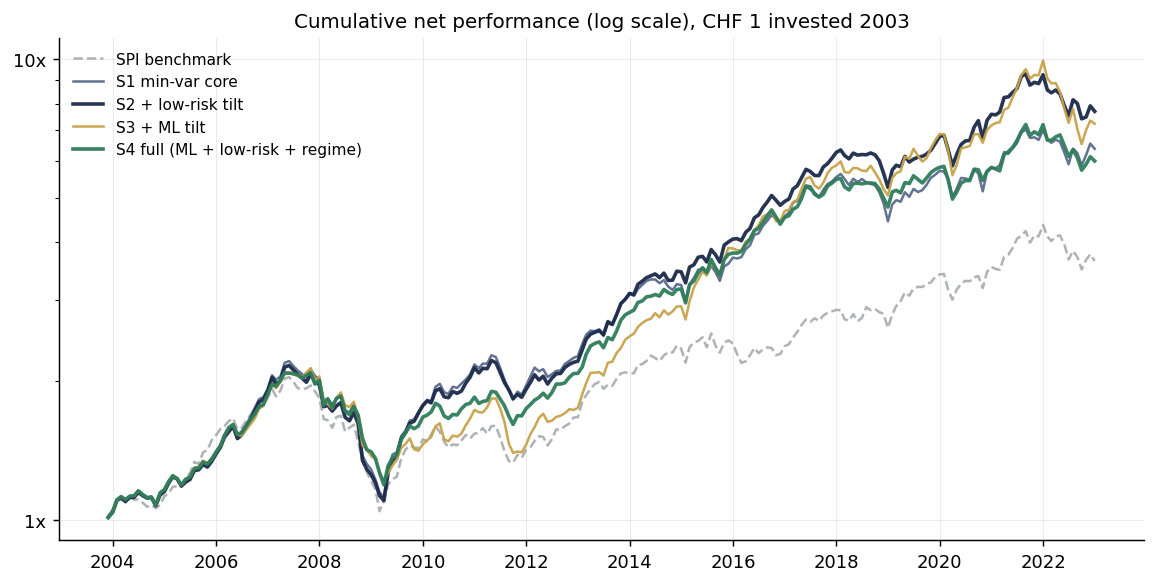

In [21]:
def fmt_pct(y, _):
    return f'{y:.0f}x'

# 1. Cumulative performance, log scale
fig, ax = plt.subplots(figsize=(9, 4.6))
for k in ['SPI', 'S1', 'S2', 'S3', 'S4']:
    cum = (1 + rets_net[k]).cumprod()
    ax.plot(cum.index, cum.values, label=LABELS[k], color=COLORS[k],
            lw=2.0 if k in ('S2', 'S4') else 1.4, alpha=0.95 if k != 'SPI' else 0.8,
            ls='-' if k != 'SPI' else '--')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(FuncFormatter(fmt_pct))
ax.set_title('Cumulative net performance (log scale), CHF 1 invested 2003', fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc='upper left')
plt.tight_layout(); plt.savefig(f'{FIG}/cumulative.png'); plt.show()

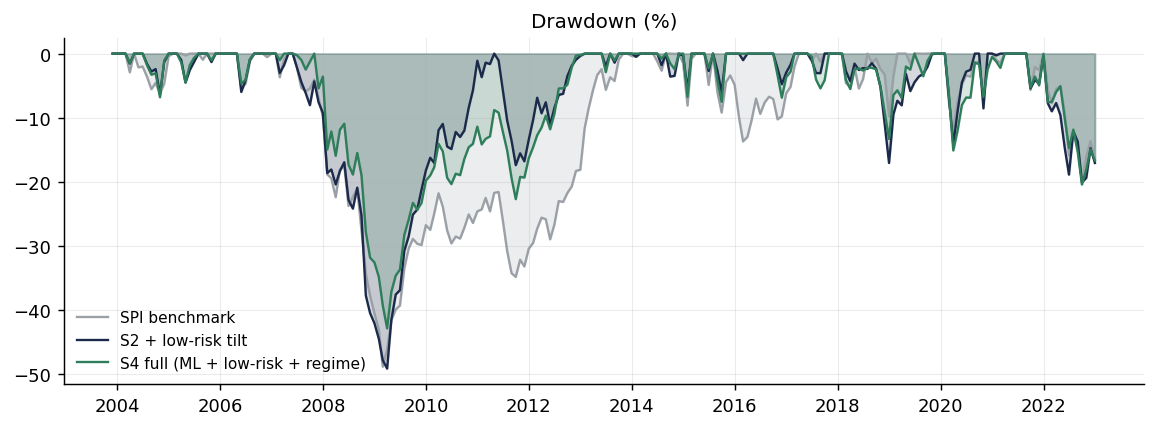

In [22]:
# 2. Drawdown curves
fig, ax = plt.subplots(figsize=(9, 3.4))
for k in ['SPI', 'S2', 'S4']:
    dd = drawdown(rets_net[k]) * 100
    ax.fill_between(dd.index, dd.values, 0, color=COLORS[k], alpha=0.18)
    ax.plot(dd.index, dd.values, color=COLORS[k], lw=1.3, label=LABELS[k])
ax.set_title('Drawdown (%)', fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc='lower left')
plt.tight_layout(); plt.savefig(f'{FIG}/drawdown.png'); plt.show()

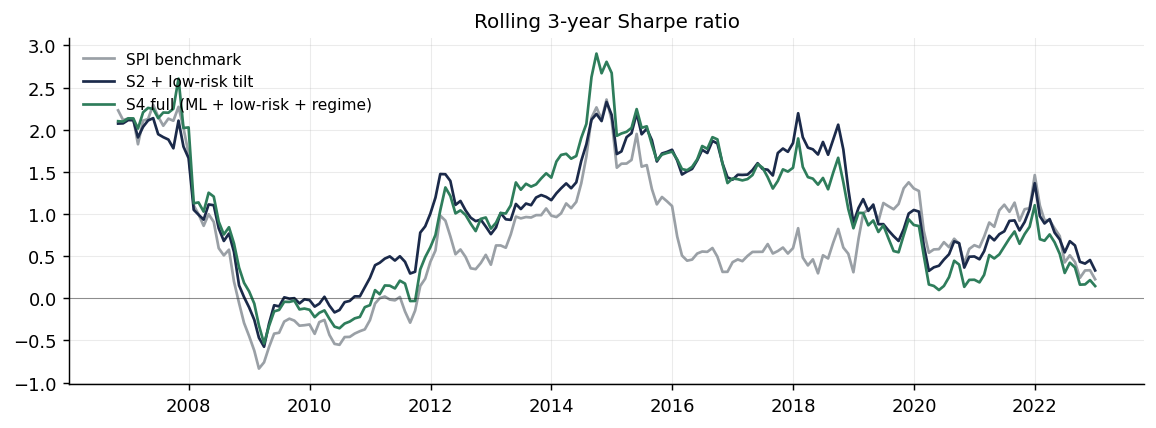

In [23]:
# 3. Rolling 3-year Sharpe ratio
fig, ax = plt.subplots(figsize=(9, 3.4))
for k in ['SPI', 'S2', 'S4']:
    rs = rolling_sharpe(rets_net[k], 36)
    ax.plot(rs.index, rs.values, color=COLORS[k], lw=1.5, label=LABELS[k])
ax.axhline(0, color='k', lw=0.6, alpha=0.4)
ax.set_title('Rolling 3-year Sharpe ratio', fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc='upper left')
plt.tight_layout(); plt.savefig(f'{FIG}/rolling_sharpe.png'); plt.show()

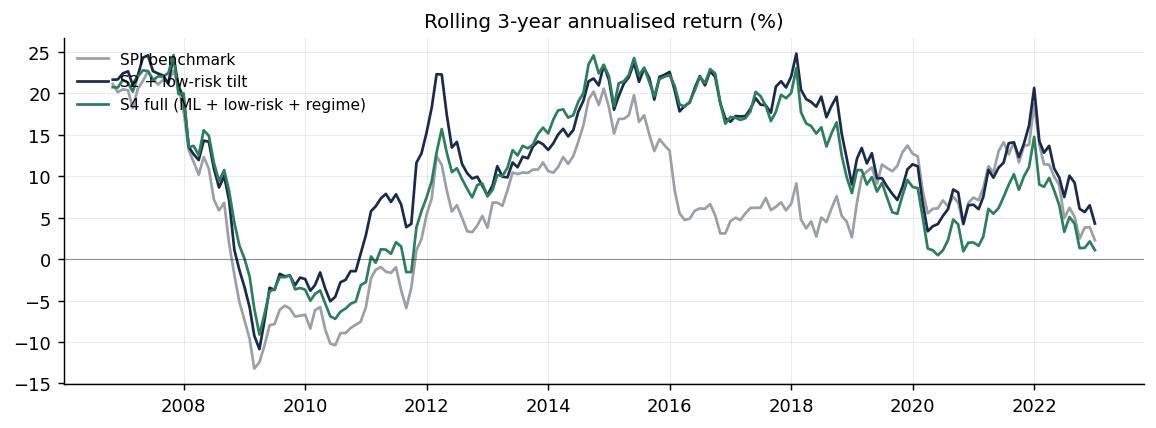

In [24]:
# 3b. Rolling 3-year annualised return
fig, ax = plt.subplots(figsize=(9, 3.4))
for k in ['SPI', 'S2', 'S4']:
    rr = rolling_return(rets_net[k], 36) * 100
    ax.plot(rr.index, rr.values, color=COLORS[k], lw=1.5, label=LABELS[k])
ax.axhline(0, color='k', lw=0.6, alpha=0.4)
ax.set_title('Rolling 3-year annualised return (%)', fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc='upper left')
plt.tight_layout(); plt.savefig(f'{FIG}/rolling_return.png'); plt.show()

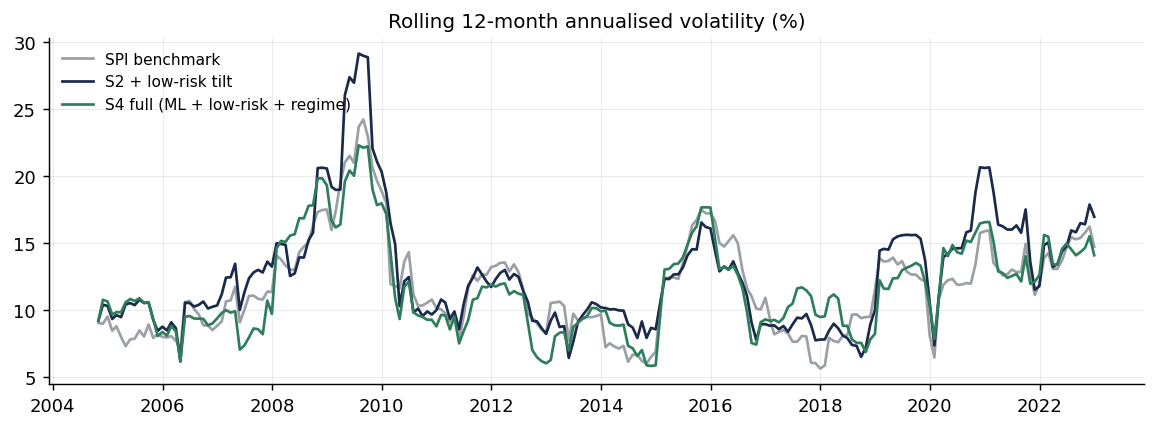

In [25]:
# 4. Rolling 12-month volatility
fig, ax = plt.subplots(figsize=(9, 3.4))
for k in ['SPI', 'S2', 'S4']:
    rv = rolling_vol(rets_net[k], 12) * 100
    ax.plot(rv.index, rv.values, color=COLORS[k], lw=1.5, label=LABELS[k])
ax.set_title('Rolling 12-month annualised volatility (%)', fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc='upper left')
plt.tight_layout(); plt.savefig(f'{FIG}/rolling_vol.png'); plt.show()

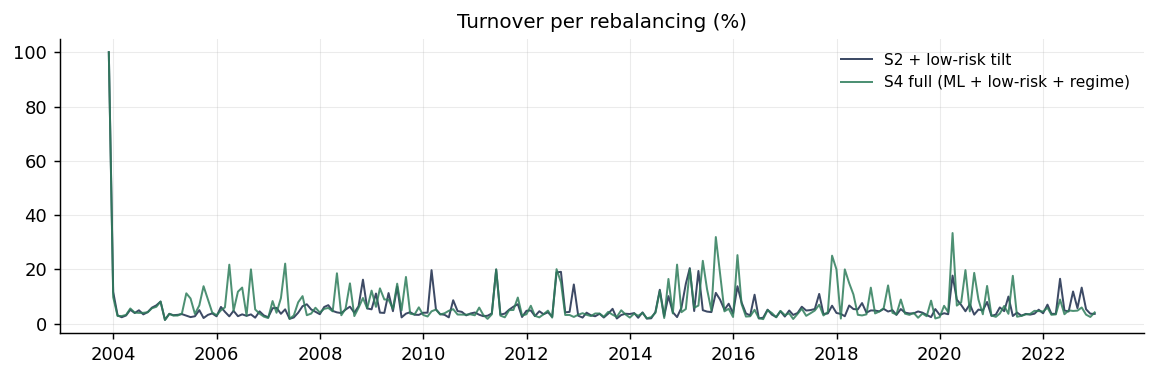

In [26]:
# 5. Turnover per rebalancing
fig, ax = plt.subplots(figsize=(9, 3.0))
for k in ['S2', 'S4']:
    to = results[k]['turnover'] * 100
    ax.plot(to.index, to.values, color=COLORS[k], lw=1.1, label=LABELS[k], alpha=0.85)
ax.set_title('Turnover per rebalancing (%)', fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc='upper right')
plt.tight_layout(); plt.savefig(f'{FIG}/turnover.png'); plt.show()

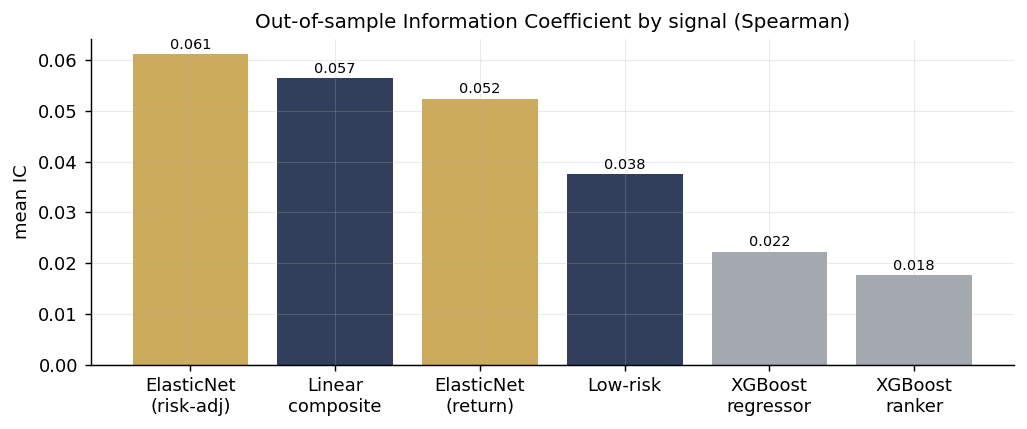

In [27]:
# 6. Information Coefficient by signal
fig, ax = plt.subplots(figsize=(8, 3.4))
order_ic = ['ml_radj', 'linear', 'enet', 'lowrisk', 'xgbr', 'ranker']
names_ic = {'ml_radj': 'ElasticNet\n(risk-adj)', 'linear': 'Linear\ncomposite',
            'enet': 'ElasticNet\n(return)', 'lowrisk': 'Low-risk',
            'xgbr': 'XGBoost\nregressor', 'ranker': 'XGBoost\nranker'}
vals_ic = [ic_table.loc[k, 'mean IC'] for k in order_ic]
cols_ic = [GOLD if k in ('ml_radj', 'enet') else (NAVY if k in ('linear', 'lowrisk') else GREY) for k in order_ic]
ax.bar([names_ic[k] for k in order_ic], vals_ic, color=cols_ic, alpha=0.9)
ax.axhline(0, color='k', lw=0.6)
ax.set_title('Out-of-sample Information Coefficient by signal (Spearman)', fontsize=11)
ax.set_ylabel('mean IC')
for i, v in enumerate(vals_ic):
    ax.text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout(); plt.savefig(f'{FIG}/ic.png'); plt.show()